In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy as sp
import re
from collections import Counter
from copy import deepcopy
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator
import os
import ast
from scipy import stats 
from scipy.odr import Model, RealData, ODR
from scipy.stats import spearmanr, wilcoxon, ttest_1samp, ranksums, gaussian_kde, fisher_exact, ttest_ind, kruskal, mannwhitneyu, binomtest
from matplotlib import gridspec
from matplotlib_venn import venn3
import zipfile
from glob import glob
import gzip
import tarfile
from itertools import combinations
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, FixedLocator
from matplotlib.colors import LinearSegmentedColormap
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.patches as mpatches
from itertools import combinations
import pingouin as pg


print("packages have been successfully read in!")

packages have been successfully read in!


In [2]:
## Setting directories and reading in data 
# Reflect output from AAS pipeline (proj_dir), output folder (aa_subs_dir), and sample map for each sample 
# For reproducing analysis of the following datasets, it is highly recommended to maintain the same project directory structure... 

print("loading directories...")
CODE_DIR        = '/Users/alexmaropakis/Projects/BrainDecode/'   
PROJ_DIR        = '/Users/alexmaropakis/Projects/Project_BrainDecode/'
SAMPLE_MAPS_DIR = CODE_DIR + 'Dependencies/Sample_maps/'
SUPP_DIR        = PROJ_DIR + '/Supplementary_Tables/Neurodegeneration/'
RAW_DIR         = PROJ_DIR + 'Raw_Quant/Neurodegeneration/'
INDIR           = PROJ_DIR + 'Analysis_Inputs/'
OUTDIR          = CODE_DIR + 'Dependencies/Analysis_Outputs/'
DEPDIR          = CODE_DIR + 'Dependencies/'
FRAG_DIR        = PROJ_DIR + 'frag_output/'   # FragPipe: <region>/<batch>/<plex>_1/ holds psm.tsv + per-fraction *.tsv
PLOT_DIR        = PROJ_DIR + 'Plots/Neurodegeneration/'

# Dataset specific general dirs 
Ping_INDIR      = INDIR + 'Ping_2018/'
Ping_OUTDIR     = OUTDIR + 'Ping_2018/'
Ping_DEPDIR     = DEPDIR + 'Ping_2018/'
Ping_FRAG_DIR   = FRAG_DIR + 'Ping_2018/'
Ping_PLOT_DIR   = PLOT_DIR + 'Ping_2018/'

Bai_INDIR       = INDIR + 'Bai_2020/'
Bai_OUTDIR      = OUTDIR + 'Bai_2020/'
Bai_DEPDIR      = DEPDIR + 'Bai_2020/'
Bai_FRAG_DIR    = FRAG_DIR + 'Bai_2020/'
Bai_PLOT_DIR    = PLOT_DIR + 'Bai_2020/'

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(SUPP_DIR, exist_ok=True)
os.makedirs(RAW_DIR, exist_ok=True)

## Define dataset/TMT set folders 

# Ping et al., 2018 
# Anterior cingulate gyrus (ACG) and frontal cortex (FC) datasets, each with 5 batches (B1-B5)
# B1
acgb1_proj_dir      = Ping_OUTDIR + 'acg/b1/'
acgb1_aa_subs_dir   = Ping_INDIR + 'acg/b1/'
acgb1_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb1.xlsx')
acgb1_samples       = ['S'+str(i) for i in list(set(acgb1_sample_map['TMT plex']))]
acgb1_frag            = Ping_FRAG_DIR + 'acg/b1/acgb1_1/'

# B2
acgb2_proj_dir      = Ping_OUTDIR + 'acg/b2/'
acgb2_aa_subs_dir   = Ping_INDIR + 'acg/b2/'
acgb2_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb2.xlsx')
acgb2_samples       = ['S'+str(i) for i in list(set(acgb2_sample_map['TMT plex']))]
acgb2_frag            = Ping_FRAG_DIR + 'acg/b2/acgb2_1/'

# B3
acgb3_proj_dir      = Ping_OUTDIR + 'acg/b3/'
acgb3_aa_subs_dir   = Ping_INDIR + 'acg/b3/'
acgb3_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb3.xlsx')
acgb3_samples       = ['S'+str(i) for i in list(set(acgb3_sample_map['TMT plex']))]
acgb3_frag            = Ping_FRAG_DIR + 'acg/b3/acgb3_1/'

# B4
acgb4_proj_dir      = Ping_OUTDIR + 'acg/b4/'
acgb4_aa_subs_dir   = Ping_INDIR + 'acg/b4/'
acgb4_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb4.xlsx')
acgb4_samples       = ['S'+str(i) for i in list(set(acgb4_sample_map['TMT plex']))]
acgb4_frag          = Ping_FRAG_DIR + 'acg/b4/acgb4_1/'

# B5
acgb5_proj_dir      = Ping_OUTDIR + 'acg/b5/'
acgb5_aa_subs_dir   = Ping_INDIR + 'acg/b5/'
acgb5_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb5.xlsx')
acgb5_samples       = ['S'+str(i) for i in list(set(acgb5_sample_map['TMT plex']))]
acgb5_frag            = Ping_FRAG_DIR + 'acg/b5/acgb5_1/'

## FRONTAL CORTEX
# B1
fcb1_proj_dir      = Ping_OUTDIR + 'fc/b1/'
fcb1_aa_subs_dir   = Ping_INDIR + 'fc/b1/'
fcb1_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb1.xlsx')
fcb1_samples       = ['S'+str(i) for i in list(set(fcb1_sample_map['TMT plex']))]
fcb1_frag            = Ping_FRAG_DIR + 'fc/b1/fcb1_1/'

# B2
fcb2_proj_dir      = Ping_OUTDIR + 'fc/b2/'
fcb2_aa_subs_dir   = Ping_INDIR + 'fc/b2/'
fcb2_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb2.xlsx')
fcb2_samples       = ['S'+str(i) for i in list(set(fcb2_sample_map['TMT plex']))]
fcb2_frag            = Ping_FRAG_DIR + 'fc/b2/fcb2_1/'

# B3
fcb3_proj_dir      = Ping_OUTDIR + 'fc/b3/'
fcb3_aa_subs_dir   = Ping_INDIR + 'fc/b3/'
fcb3_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb3.xlsx')
fcb3_samples       = ['S'+str(i) for i in list(set(fcb3_sample_map['TMT plex']))]
fcb3_frag            = Ping_FRAG_DIR + 'fc/b3/fcb3_1/'

# B4
fcb4_proj_dir      = Ping_OUTDIR + 'fc/b4/'
fcb4_aa_subs_dir   = Ping_INDIR + 'fc/b4/'
fcb4_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb4.xlsx')
fcb4_samples       = ['S'+str(i) for i in list(set(fcb4_sample_map['TMT plex']))]
fcb4_frag            = Ping_FRAG_DIR + 'fc/b4/fcb4_1/'

# B5
fcb5_proj_dir      = Ping_OUTDIR + 'fc/b5/'
fcb5_aa_subs_dir   = Ping_INDIR + 'fc/b5/'
fcb5_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb5.xlsx')
fcb5_samples       = ['S'+str(i) for i in list(set(fcb5_sample_map['TMT plex']))]
fcb5_frag            = Ping_FRAG_DIR + 'fc/b5/fcb5_1/'


# Bai et al., 2020 
pooled_proj_dir      = Bai_OUTDIR
pooled_aa_subs_dir   = Bai_INDIR
pooled_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_pooled.xlsx')
pooled_samples       = ['S'+str(i) for i in list(set(pooled_sample_map['TMT plex']))]
pooled_frag           = Bai_FRAG_DIR + 'pooled_1/'


#lists to quickly index dataset-specific sample maps from just the dataset name
datasets = ['acgb1', 'acgb2', 'acgb3', 'acgb4', 'acgb5', 'fcb1', 'fcb2', 'fcb3', 'fcb4', 'fcb5', 'pooled']
acg_datasets = ['acgb1', 'acgb2', 'acgb3', 'acgb4', 'acgb5']
fc_datasets = ['fcb1','fcb2','fcb3','fcb4','fcb5']

data_dir_list = [acgb1_aa_subs_dir, acgb2_aa_subs_dir, acgb3_aa_subs_dir, acgb4_aa_subs_dir, acgb5_aa_subs_dir, fcb1_aa_subs_dir, fcb2_aa_subs_dir, fcb3_aa_subs_dir, fcb4_aa_subs_dir, fcb5_aa_subs_dir, pooled_aa_subs_dir]
proj_dir_list = [acgb1_proj_dir, acgb2_proj_dir, acgb3_proj_dir, acgb4_proj_dir, acgb5_proj_dir, fcb1_proj_dir, fcb2_proj_dir, fcb3_proj_dir, fcb4_proj_dir, fcb5_proj_dir, pooled_proj_dir]
acg_proj_dir_list = [acgb1_proj_dir, acgb2_proj_dir, acgb3_proj_dir, acgb4_proj_dir, acgb5_proj_dir]
fc_proj_dir_list = [fcb1_proj_dir, fcb2_proj_dir, fcb3_proj_dir, fcb4_proj_dir, fcb5_proj_dir]
pooled_proj_dir_list = [pooled_proj_dir]

samples_list = [acgb1_samples, acgb2_samples, acgb3_samples, acgb4_samples, acgb5_samples, fcb1_samples, fcb2_samples, fcb3_samples, fcb4_samples, fcb5_samples, pooled_samples]
sample_map_list = [acgb1_sample_map, acgb2_sample_map, acgb3_sample_map, acgb4_sample_map, acgb5_sample_map, fcb1_sample_map, fcb2_sample_map, fcb3_sample_map, fcb4_sample_map, fcb5_sample_map, pooled_sample_map]
acg_samples_list = [acgb1_samples, acgb2_samples, acgb3_samples, acgb4_samples, acgb5_samples]
fc_samples_list = [fcb1_samples, fcb2_samples, fcb3_samples, fcb4_samples, fcb5_samples]
pooled_samples_list = [pooled_samples]

frag_dir_list = [acgb1_frag, acgb2_frag, acgb3_frag, acgb4_frag, acgb5_frag, fcb1_frag, fcb2_frag, fcb3_frag, fcb4_frag, fcb5_frag, pooled_frag]
acg_frag_dir_list = [acgb1_frag, acgb2_frag, acgb3_frag, acgb4_frag, acgb5_frag]
fc_frag_dir_list = [fcb1_frag, fcb2_frag, fcb3_frag, fcb4_frag, fcb5_frag]
pooled_frag_dir_list = [pooled_frag]

print("directories loaded successfully!")

loading directories...
directories loaded successfully!


In [3]:
# Read in data generated from Dependencies code
# If dependencies not generated yet, go back and generate in Analysis_Dependnecies.ipynb
# Since clustering a lot of data, must combine dataframes... 

# Cluster SAAP_quant_df 
SAAP_quant_df_acg = pd.read_excel(Ping_DEPDIR+'acg/SAAP_precursor_reporter_quant.xlsx', index_col=0)
SAAP_quant_df_fc = pd.read_excel(Ping_DEPDIR+'fc/SAAP_precursor_reporter_quant.xlsx', index_col=0)
SAAP_quant_df_pooled = pd.read_excel(Bai_DEPDIR+'SAAP_precursor_reporter_quant.xlsx', index_col=0)

SAAP_quant_df_list = [SAAP_quant_df_acg, SAAP_quant_df_fc, SAAP_quant_df_pooled]
SAAP_quant_df = pd.concat([SAAP_quant_df_acg, SAAP_quant_df_fc, SAAP_quant_df_pooled])
SAAP_quant_df = SAAP_quant_df[SAAP_quant_df['Sample Type'] != 'Unknown'] # Filter out GIS sample types
print(SAAP_quant_df)

# Cluster fragment ion data 
pos_prob_df_acg = pd.read_csv(Ping_DEPDIR+'acg/Position_probability_fragment_ion_data.csv', index_col=0)
pos_prob_df_fc = pd.read_csv(Ping_DEPDIR+'fc/Position_probability_fragment_ion_data.csv', index_col=0)
pos_prob_df_pooled = pd.read_csv(Bai_DEPDIR+'Position_probability_fragment_ion_data.csv', index_col=0)

pos_prob_df_list = [pos_prob_df_acg, pos_prob_df_fc, pos_prob_df_pooled]
pos_prob_df = pd.concat([pos_prob_df_acg, pos_prob_df_fc, pos_prob_df_pooled])
print(pos_prob_df)

frag_dict_acg = pickle.load(open(Ping_DEPDIR+'acg/Fragment_ion_dict.p', 'rb'))
frag_dict_fc = pickle.load(open(Ping_DEPDIR+'fc/Fragment_ion_dict.p', 'rb'))
frag_dict_pooled = pickle.load(open(Bai_DEPDIR+'Fragment_ion_dict.p', 'rb'))
frag_dict = {**frag_dict_acg, **frag_dict_fc, **frag_dict_pooled}

frag_df_acg = pd.read_excel(Ping_DEPDIR+'acg/fragments_per_saap_4barplot_allDS.xlsx', index_col=0)
frag_df_fc = pd.read_excel(Ping_DEPDIR+'fc/fragments_per_saap_4barplot_allDS.xlsx', index_col=0)
frag_df_pooled = pd.read_excel(Bai_DEPDIR+'fragments_per_saap_4barplot_allDS.xlsx', index_col=0)
frag_df = pd.concat([frag_df_acg, frag_df_fc, frag_df_pooled])
frag_df = frag_df.groupby(['Bin', 'Used'], as_index=False)['Count'].sum()
CATS = ['0', '1', '2-5', '6-10', '>10']
frag_df['Bin'] = pd.Categorical(frag_df['Bin'], categories=CATS, ordered=True)
frag_df = frag_df.sort_values('Bin').reset_index(drop=True)
# print(frag_df)

# Dataset metrics 
ds_metrics_acg = pd.read_excel(Ping_DEPDIR+'acg/dataset_metrics.xlsx', index_col=0)
ds_metrics_fc = pd.read_excel(Ping_DEPDIR+'fc/dataset_metrics.xlsx', index_col=0)
ds_metrics_pooled = pd.read_excel(Bai_DEPDIR+'dataset_metrics.xlsx', index_col=0)
ds_metrics = pd.concat([ds_metrics_acg, ds_metrics_fc, ds_metrics_pooled])

           Dataset         MTP_seq          BP_seq  aa_sub tmt_set  \
Row Number                                                           
0            acgb1        SSTPEEPK        SSTPEEVK  V to P      S1   
1            acgb1        SSTPEEPK        SSTPEEVK  V to P      S1   
3            acgb1        SSTPEEPK        SSTPEEVK  V to P      S1   
4            acgb1        SSTPEEPK        SSTPEEVK  V to P      S1   
5            acgb1        SSTPEEPK        SSTPEEVK  V to P      S1   
...            ...             ...             ...     ...     ...   
18905       pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
18906       pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
18907       pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
18908       pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
18909       pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   

            Positional_probability  spectral_entropy  delta_RT  SAAP_PEP  \
Row Number   

# Filtering Steps

## Remove immunoglobulins and trypsin-mapping SAAPs 

In [4]:
## Assign each SAAP a gene and accession & drop Igs/trypsins 

# Build dictionaries of peptide ID, gene, and accessions 
acc_gene = {}
acc_desc = {}
for frag_dir in frag_dir_list:
    cols = ['Protein ID', 'Gene', 'Protein Description', 'Mapped Proteins', 'Mapped Genes']
    psm=pd.read_csv(frag_dir +'psm.tsv', sep='\t', low_memory=False, usecols=lambda c: c in cols)

    for acc, gene, desc in zip(psm['Protein ID'], psm.get('Gene', ''), psm.get('Protein Description', '')):
        a = str(acc)
        if pd.notna(desc) and str(desc).strip():
            acc_desc.setdefault(a, str(desc).strip())
        if pd.notna(gene) and str(gene).strip():
            acc_gene.setdefault(a, str(gene).strip())
print(f'{len(acc_desc):,} reference proteins parsed from psm.tsv')

seq_to_proteins = {}
for dataset, frag_dir in zip(datasets, frag_dir_list):
    cols = ['Peptide', 'Protein', 'Mapped Proteins']
    psm=pd.read_csv(frag_dir +'psm.tsv', sep='\t', low_memory=False, usecols=lambda c: c in cols)
    for seq, prot, mapped in zip(psm['Peptide'], psm['Protein'].astype(str),
                                 psm.get('Mapped Proteins', pd.Series('')).astype(str)):
        if prot and prot != 'nan':
            full = prot if mapped in ('', 'nan') else prot + ';' + mapped.replace(', ', ';')
            seq_to_proteins.setdefault((dataset, seq), full)
print(f'{len(seq_to_proteins):,} unique (tissue, peptide) pairs indexed across {len(frag_dir_list)} psm.tsv files')

def prot_to_acc(protein_str):
    lead_only = True
    accs = []
    for tok in str(protein_str).split(';'):
        if tok.startswith('MTP'):
            continue
        m = re.match(r'(?:sp|tr)\|([^|]+)\|', tok) or re.match(r'^([A-Z0-9][A-Z0-9-]+)$', tok)
        if m:
            accs.append((m.group(1)))  
    accs = list(dict.fromkeys(accs))  
    return accs[:1] if lead_only else accs

row_accs = [prot_to_acc(seq_to_proteins.get((ds, bp), ''))
            for ds, bp in zip(SAAP_quant_df['Dataset'], SAAP_quant_df['BP_seq'])]
row_genes = [[acc_gene.get(a, '') for a in accs] for accs in row_accs]
row_descs = [[acc_desc.get(a, '') for a in accs] for accs in row_accs]

def first_nonempty(values):
    return next((v for v in values if v), '')

# append observations to SAAP_quant_df
SAAP_quant_df['Source_accessions'] = [';'.join(accs) for accs in row_accs]
SAAP_quant_df['Source_gene']       = [first_nonempty(g) for g in row_genes]
SAAP_quant_df['Source_protein']    = [first_nonempty(d) for d in row_descs]
print(SAAP_quant_df[['MTP_seq', 'BP_seq', 'Dataset', 'Source_gene', 'Source_protein']].to_string())

19,906 reference proteins parsed from psm.tsv
1,086,928 unique (tissue, peptide) pairs indexed across 11 psm.tsv files
                                                MTP_seq                                       BP_seq Dataset   Source_gene                                                                                              Source_protein
Row Number                                                                                                                                                                                                                            
0                                              SSTPEEPK                                     SSTPEEVK   acgb1          CFL1                                                                                                   Cofilin-1
1                                              SSTPEEPK                                     SSTPEEVK   acgb1          CFL1                                                                  

In [5]:
# flag immunoglobulin (antibody chains) and trypsin (digestion contaminant) source proteins.
# Matching is gene- and accession-based to avoid false positives such as Ig-superfamily
# members, IgLON, anti-trypsin, or chymotrypsin.
ig_gene_re   = re.compile(r'(?i)^Ig[hkl][vjdcmage0-9]')
ig_desc_re   = re.compile(r'(?i)^(immunoglobulin|ig)[ -](heavy|kappa|lambda|gamma|mu|alpha|delta|epsilon|j)')
tryp_desc_re = re.compile(r'(?i)\btrypsin')
tryp_skip_re = re.compile(r'(?i)(anti-?trypsin|trypsin inhibitor|chymotrypsin)')
TRYPSIN_ACCESSIONS = {'P00761', 'P00760'}  # Sus scrofa / Bos taurus digestion trypsin contaminants

def is_immunoglobulin(accs):
    return any(ig_gene_re.match(acc_gene.get(a, '')) or acc_gene.get(a, '').lower() == 'jchain'
               or ig_desc_re.match(acc_desc.get(a, '')) for a in accs)

def is_trypsin(accs):
    return any(a in TRYPSIN_ACCESSIONS or
               (tryp_desc_re.search(acc_desc.get(a, '')) and not tryp_skip_re.search(acc_desc.get(a, '')))
               for a in accs)

SAAP_quant_df['immunoglobulin'] = ['YES' if is_immunoglobulin(accs) else 'NO' for accs in row_accs]
SAAP_quant_df['trypsin']        = ['YES' if is_trypsin(accs) else 'NO' for accs in row_accs]
print(f"\n{(SAAP_quant_df['immunoglobulin'] == 'YES').sum():,} SAAP observations match immunoglobulins")
print(f"{(SAAP_quant_df['trypsin'] == 'YES').sum():,} SAAP observations match trypsin")
print('immunoglobulin source proteins removed:',
      sorted(SAAP_quant_df.loc[SAAP_quant_df['immunoglobulin'] == 'YES', 'Source_protein'].unique()))
print('trypsin source proteins removed:',
      sorted(SAAP_quant_df.loc[SAAP_quant_df['trypsin'] == 'YES', 'Source_accessions'].unique()))


800 SAAP observations match immunoglobulins
0 SAAP observations match trypsin
immunoglobulin source proteins removed: ['HCG2043238 (Fragment)', 'Ig alpha-1 chain C region', 'Ig gamma-1 chain C region', 'Ig gamma-3 chain C region', 'Ig heavy chain V-III region BUR', 'Ig heavy chain V-III region BUT', 'Ig heavy chain V-III region GAL', 'Ig heavy chain V-III region TIL', 'Ig heavy chain V-III region VH26', 'Ig kappa chain C region', 'Ig kappa chain V-I region AU', 'Ig kappa chain V-I region EU', 'Ig kappa chain V-I region Lay', 'Ig kappa chain V-I region Ni', 'Ig kappa chain V-I region Walker', 'Ig kappa chain V-III region SIE', 'Ig kappa chain V-III region WOL', 'Ig kappa chain V-IV region Len', 'Ig lambda chain V-III region LOI', 'Ig lambda chain V-V region DEL', 'Ig mu chain C region', 'Immunoglobulin lambda-like polypeptide 5', 'Protein IGHV3-15 (Fragment)', 'Protein IGHV3-35 (Fragment)', 'Protein IGHV3-49', 'Protein IGHV3-72', 'Protein IGHV3OR16-12 (Fragment)', 'Protein IGHV3OR16-9 

In [6]:
# Save as Supplemental_Data_2.SAAP_quantification_neurodegeneration_clustered.xlsx
SAAP_quant_df.to_excel(SUPP_DIR+'Supplemental_Data_2.SAAP_quantification_neurodegeneration_clustered.xlsx')

39
0
853
          Category  Count
0  Immunoglobulins     39
1         Trypsins      0
2            SAAPs    853


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_94334/1809934607.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x='Category', y='Count',palette='Set2',alpha=1)


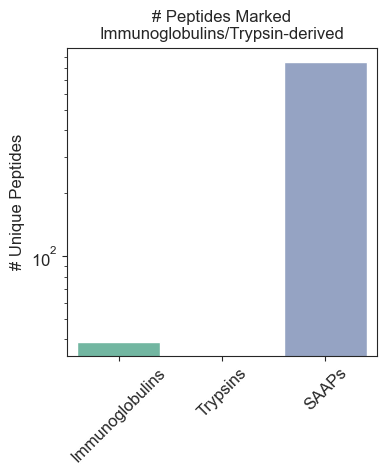

In [7]:
# Plot the number of trypsin/immunoglobulin-matching peptides 
n_immunoglobulin = SAAP_quant_df.loc[SAAP_quant_df['immunoglobulin'] == 'YES', 'Source_protein'].nunique()
print(n_immunoglobulin)

n_trypsin = SAAP_quant_df.loc[SAAP_quant_df['trypsin'] == 'YES', 'Source_protein'].nunique()
print(n_trypsin)

n_main_SAAP = SAAP_quant_df.loc[(SAAP_quant_df['trypsin'] == 'NO') & (SAAP_quant_df['immunoglobulin'] == 'NO'), 'Source_protein'].nunique()
print(n_main_SAAP)

plot_df = pd.DataFrame({'Category': ['Immunoglobulins', 'Trypsins', 'SAAPs'],'Count': [n_immunoglobulin, n_trypsin, n_main_SAAP]})
print(plot_df)

plt.figure(figsize=(4,4))
sns.set_style(style='ticks')
ax = sns.barplot(data=plot_df, x='Category', y='Count',palette='Set2',alpha=1)
ax.set_yscale('log')
ax.set_xlabel('')
ax.set_ylabel('# Unique Peptides',fontsize=12)
ax.set_title('# Peptides Marked\nImmunoglobulins/Trypsin-derived',fontsize=12)
ax.tick_params(axis='x',rotation=45,labelsize=12)
ax.tick_params(axis='y',labelsize=12)

plt.savefig(PLOT_DIR+'Igg_trypsin_filtering_barplot.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Igg_trypsin_filtering_barplot.png',dpi=600,bbox_inches='tight')

In [8]:
drop_mask = (SAAP_quant_df['immunoglobulin'] == 'YES') | (SAAP_quant_df['trypsin'] == 'YES')
SAAP_quant_df = SAAP_quant_df.loc[~drop_mask].reset_index(drop=True)

## Rescue SAAPs with RT and spectral prediction support from positional probability filtering
A SAAP's positional probability is only high when the MS2 spectrum has the b/y ions
flanking the substituted residue. Low-abundance or poorly-fragmenting peptides often
lack those ions, so a real SAAP can score low purely from missing fragments. A hard
positional-probability cut therefore discards genuine SAAPs.

To recover them we use two orthogonal MSBooster scores from the *_edited.pin files:

  weighted_spectral_entropy : how well the observed spectrum matches the predicted
                              spectrum for the assigned SAAP (higher = better).
  delta_RT_loess            : difference between observed and predicted retention
                              time, loess-calibrated and already absolute
                              (lower = better). Orthogonal to spectral matching.

Both thresholds are calibrated against DECOYS. Each pin row has Label = 1 (target) or
-1 (decoy). We set each threshold to admit a chosen small fraction of decoys
(DECOY_ADMIT), giving every cutoff a known decoy-admission rate rather than an
arbitrary number.

Rule: keep a SAAP if it is confidently localized (positional probability >= cut),
OR if it is uncertainly localized but passes BOTH the entropy and RT thresholds.

Note: the entropy score is one-sided (it only checks the SAAP matches itself), so it
cannot reject an isobaric substitution like I<->L where the SAAP and base peptide give
the same spectrum. Those land at RAAS ~ 0; the check at the end reports how many
rescued SAAPs fall there.

Requires:
  - SAAP_quant_df with 'Positional_probability' and per-SAAP
    'spectral_entropy' and 'delta_RT' columns
  - the *_edited.pin files, used here only to calibrate thresholds from decoys.

In [9]:
## Localization rescue of SAAPs using MSBooster spectral entropy and RT agreement
pos_prob_cut = 0.9
decoy_admit = 0.05  # 5%

# Calibrate thresholds per plex (no pooling across datasets)
thresholds = {}  # ds -> (entropy_thresh, rt_thresh)
for ds, frag_dir in zip(datasets, frag_dir_list):
    ent_decoy, rt_decoy = [], []
    for f in glob(frag_dir + '*_edited.pin'):
        cols = ['Label', 'weighted_spectral_entropy', 'delta_RT_loess']
        d = pd.read_csv(f, sep='\t', usecols=cols, low_memory=False)
        dec = d[d['Label'] == -1]
        ent_decoy.append(dec['weighted_spectral_entropy'].values)
        rt_decoy.append(dec['delta_RT_loess'].values)
    if not ent_decoy:
        continue
    ent_decoy = np.concatenate(ent_decoy)
    rt_decoy  = np.concatenate(rt_decoy)
    entropy_thresh = np.nanpercentile(ent_decoy, 100 * (1 - decoy_admit))
    rt_thresh      = np.nanpercentile(rt_decoy, 100 * decoy_admit)
    thresholds[ds] = (entropy_thresh, rt_thresh)
    print(f"  {ds}: entropy >= {entropy_thresh:.4f}, delta_RT <= {rt_thresh:.4f}")

ent_thresh_col = SAAP_quant_df['Dataset'].map(lambda ds: thresholds[ds][0])
rt_thresh_col  = SAAP_quant_df['Dataset'].map(lambda ds: thresholds[ds][1])

pp  = SAAP_quant_df['Positional_probability']
ent = SAAP_quant_df['spectral_entropy']
rt  = SAAP_quant_df['delta_RT']

pass_localization = pp >= pos_prob_cut
rescued = (pp < pos_prob_cut) & (ent >= ent_thresh_col) & (rt <= rt_thresh_col)

SAAP_quant_df['localization_pass'] = pass_localization
SAAP_quant_df['entropy_rescued']   = rescued
SAAP_quant_df['keep_localization'] = pass_localization | rescued

  acgb1: entropy >= 1.1906, delta_RT <= 3.2653
  acgb2: entropy >= 1.1844, delta_RT <= 3.2749
  acgb3: entropy >= 1.1576, delta_RT <= 3.2751
  acgb4: entropy >= 1.1361, delta_RT <= 3.3507
  acgb5: entropy >= 1.1430, delta_RT <= 3.2247
  fcb1: entropy >= 1.2078, delta_RT <= 3.2728
  fcb2: entropy >= 1.2297, delta_RT <= 3.2363
  fcb3: entropy >= 1.2161, delta_RT <= 3.2469
  fcb4: entropy >= 1.2199, delta_RT <= 3.1815
  fcb5: entropy >= 1.2131, delta_RT <= 3.2237
  pooled: entropy >= 0.9276, delta_RT <= 2.6941


In [10]:
# Do rescued SAAPs pile up at RAAS ~ 0? [isobaric artifacts]
# This determines what percentage of SAAPs sit at abundance comparable to base peptide 
for col in ['Reporter_RAAS', 'Prec_RAAS']:
    if col in SAAP_quant_df.columns:
        r = pd.to_numeric(SAAP_quant_df.loc[rescued, col], errors='coerce').dropna()
        if len(r):
            print(f"Rescued {col} within |RAAS|<0.5: {(r.abs() < 0.5).mean():.1%}")

Rescued Reporter_RAAS within |RAAS|<0.5: 6.6%
Rescued Prec_RAAS within |RAAS|<0.5: 6.4%


Ping 2018 (ACG): entropy >= 1.164 keeps 41.7% targets, 5.0% decoys
Ping 2018 (ACG): delta_RT <= 3.28  keeps 41.2% targets, 5.0% decoys
Ping 2018 (FC): entropy >= 1.218 keeps 29.9% targets, 5.0% decoys
Ping 2018 (FC): delta_RT <= 3.23  keeps 29.5% targets, 5.0% decoys
Bai 2020 (pooled): entropy >= 0.928 keeps 65.5% targets, 5.0% decoys
Bai 2020 (pooled): delta_RT <= 2.69  keeps 33.3% targets, 5.0% decoys


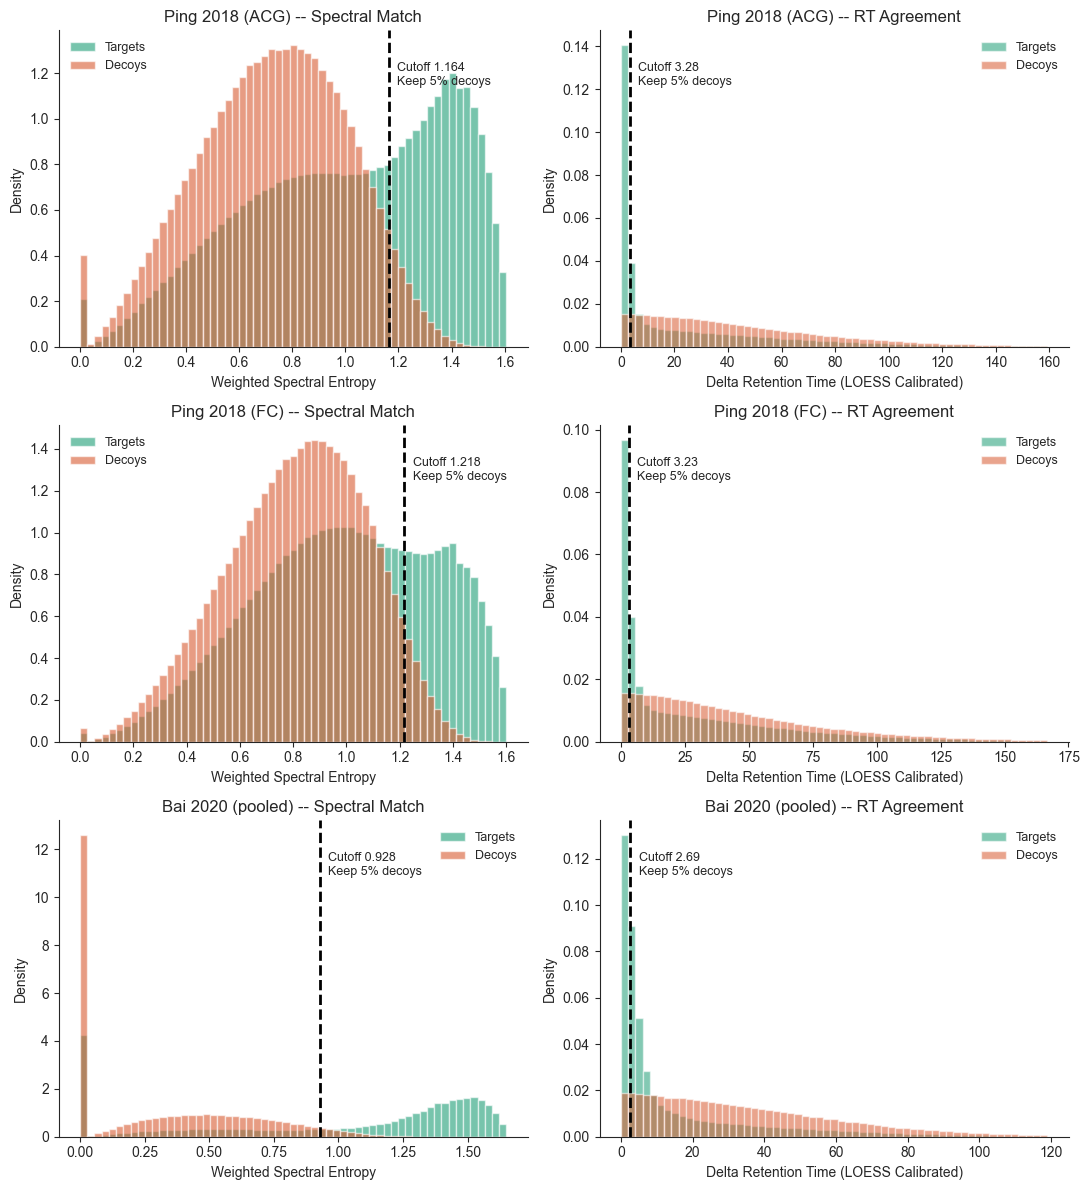

In [11]:
# Visualize the decoy-calibrated rescue thresholds, faceted per experiment

EXPERIMENT_GROUPS = {
    'Ping 2018 (ACG)': acg_frag_dir_list,
    'Ping 2018 (FC)':  fc_frag_dir_list,
    'Bai 2020 (pooled)': pooled_frag_dir_list,
}

target_color, decoy_color = '#1D9E75', '#D85A30'
fig, axes = plt.subplots(len(EXPERIMENT_GROUPS), 2, figsize=(11, 4 * len(EXPERIMENT_GROUPS)))

for row, (exp_label, exp_frag_dirs) in enumerate(EXPERIMENT_GROUPS.items()):
    ent_t, ent_d, rt_t, rt_d = [], [], [], []
    for frag_dir in exp_frag_dirs:
        for f in glob(frag_dir + '*_edited.pin'):
            d = pd.read_csv(f, sep='\t', usecols=['Label', 'weighted_spectral_entropy', 'delta_RT_loess'], low_memory=False)
            t   = d[d['Label'] == 1]
            dec = d[d['Label'] == -1]
            ent_t.append(t['weighted_spectral_entropy'].values)
            ent_d.append(dec['weighted_spectral_entropy'].values)
            rt_t.append(t['delta_RT_loess'].values)
            rt_d.append(dec['delta_RT_loess'].values)

    if not ent_t:
        print(f"  No *_edited.pin found for {exp_label} -- skipping")
        continue

    ent_t = np.concatenate(ent_t); ent_d = np.concatenate(ent_d)
    rt_t  = np.concatenate(rt_t);  rt_d  = np.concatenate(rt_d)

    ent_thresh = np.nanpercentile(ent_d, 100 * (1 - decoy_admit))
    rt_thresh  = np.nanpercentile(rt_d, 100 * decoy_admit)

    # entropy panel
    ax = axes[row, 0]
    bins = np.linspace(0, np.nanpercentile(ent_t, 99.5), 60)
    ax.hist(ent_t, bins=bins, density=True, color=target_color, alpha=0.6, label='Targets')
    ax.hist(ent_d, bins=bins, density=True, color=decoy_color, alpha=0.6, label='Decoys')
    ax.axvline(ent_thresh, color='k', ls='--', lw=2)
    ax.annotate(f"Cutoff {ent_thresh:.3f}\nKeep {decoy_admit:.0%} decoys", xy=(ent_thresh, ax.get_ylim()[1]*0.9),
                xytext=(6, 0), textcoords="offset points", va="top", fontsize=9)
    ax.set_xlabel("Weighted Spectral Entropy")
    ax.set_ylabel("Density")
    ax.set_title(f"{exp_label} -- Spectral Match")
    ax.legend(frameon=False, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

    # RT panel
    ax = axes[row, 1]
    bins = np.linspace(0, np.nanpercentile(rt_d, 99), 60)
    ax.hist(rt_t, bins=bins, density=True, color=target_color, alpha=0.55, label='Targets')
    ax.hist(rt_d, bins=bins, density=True, color=decoy_color, alpha=0.55, label='Decoys')
    ax.axvline(rt_thresh, color='k', ls='--', lw=2)
    ax.annotate(f"Cutoff {rt_thresh:.2f}\nKeep {decoy_admit:.0%} decoys", xy=(rt_thresh, ax.get_ylim()[1]*0.9),
                xytext=(6, 0), textcoords="offset points", va="top", fontsize=9)
    ax.set_xlabel("Delta Retention Time (LOESS Calibrated)")
    ax.set_ylabel("Density")
    ax.set_title(f"{exp_label} -- RT Agreement")
    ax.legend(frameon=False, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

    print(f'{exp_label}: entropy >= {ent_thresh:.3f} keeps {(ent_t>=ent_thresh).mean():.1%} targets, {(ent_d>=ent_thresh).mean():.1%} decoys')
    print(f'{exp_label}: delta_RT <= {rt_thresh:.2f}  keeps {(rt_t<=rt_thresh).mean():.1%} targets, {(rt_d<=rt_thresh).mean():.1%} decoys')

plt.tight_layout()
plt.savefig(PLOT_DIR + "rescue_threshold_target_decoy_per_experiment.pdf", bbox_inches='tight')
plt.savefig(PLOT_DIR + "rescue_threshold_target_decoy_per_experiment.png", dpi=600, bbox_inches='tight')

pooled: entropy >= 0.928 keeps 65.5% targets, 5.0% decoys
pooled: delta_RT <= 2.69  keeps 33.3% targets, 5.0% decoys


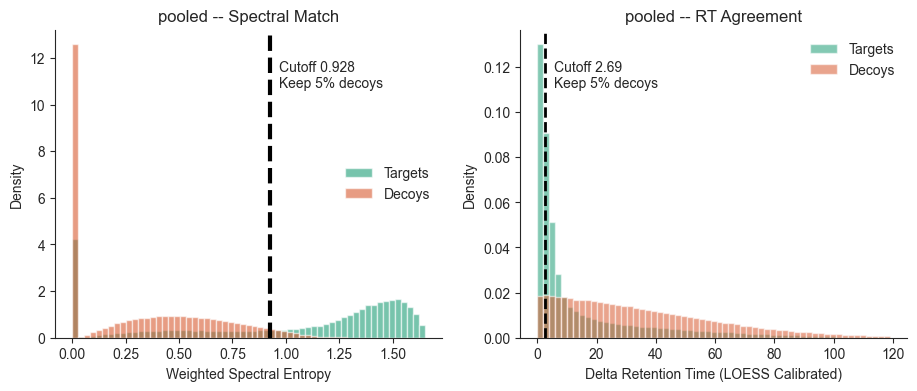

In [12]:
def plot_plex_rescue_diagnostic(ds, frag_dir, thresholds, decoy_admit=decoy_admit, save=True):
    """Single-plex target/decoy diagnostic, using the already-calibrated per-plex threshold."""
    ent_t, ent_d, rt_t, rt_d = [], [], [], []
    for f in glob(frag_dir + '*_edited.pin'):
        d = pd.read_csv(f, sep='\t', usecols=['Label', 'weighted_spectral_entropy', 'delta_RT_loess'], low_memory=False)
        t   = d[d['Label'] == 1]
        dec = d[d['Label'] == -1]
        ent_t.append(t['weighted_spectral_entropy'].values)
        ent_d.append(dec['weighted_spectral_entropy'].values)
        rt_t.append(t['delta_RT_loess'].values)
        rt_d.append(dec['delta_RT_loess'].values)

    if not ent_t:
        print(f"No *_edited.pin found for {ds}")
        return

    ent_t = np.concatenate(ent_t); ent_d = np.concatenate(ent_d)
    rt_t  = np.concatenate(rt_t);  rt_d  = np.concatenate(rt_d)
    ent_thresh, rt_thresh = thresholds[ds]  # use the real calibrated threshold, not a re-derived one

    target_color, decoy_color = '#1D9E75', '#D85A30'
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    ax = axes[0]
    bins = np.linspace(0, np.nanpercentile(ent_t, 99.5), 60)
    ax.hist(ent_t, bins=bins, density=True, color=target_color, alpha=0.6, label='Targets')
    ax.hist(ent_d, bins=bins, density=True, color=decoy_color, alpha=0.6, label='Decoys')
    ax.axvline(ent_thresh, color='k', ls='--', lw=3)
    ax.annotate(f"Cutoff {ent_thresh:.3f}\nKeep {decoy_admit:.0%} decoys", xy=(ent_thresh, ax.get_ylim()[1]*0.9),
                xytext=(6, 0), textcoords="offset points", va="top", fontsize=10)
    ax.set_xlabel("Weighted Spectral Entropy")
    ax.set_ylabel("Density")
    ax.set_title(f"{ds} -- Spectral Match")
    ax.legend(frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

    ax = axes[1]
    bins = np.linspace(0, np.nanpercentile(rt_d, 99), 60)
    ax.hist(rt_t, bins=bins, density=True, color=target_color, alpha=0.55, label='Targets')
    ax.hist(rt_d, bins=bins, density=True, color=decoy_color, alpha=0.55, label='Decoys')
    ax.axvline(rt_thresh, color='k', ls='--', lw=2)
    ax.annotate(f"Cutoff {rt_thresh:.2f}\nKeep {decoy_admit:.0%} decoys", xy=(rt_thresh, ax.get_ylim()[1]*0.9),
                xytext=(6, 0), textcoords="offset points", va="top", fontsize=10)
    ax.set_xlabel("Delta Retention Time (LOESS Calibrated)")
    ax.set_ylabel("Density")
    ax.set_title(f"{ds} -- RT Agreement")
    ax.legend(frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

    print(f'{ds}: entropy >= {ent_thresh:.3f} keeps {(ent_t>=ent_thresh).mean():.1%} targets, {(ent_d>=ent_thresh).mean():.1%} decoys')
    print(f'{ds}: delta_RT <= {rt_thresh:.2f}  keeps {(rt_t<=rt_thresh).mean():.1%} targets, {(rt_d<=rt_thresh).mean():.1%} decoys')

    if save:
        plt.savefig(PLOT_DIR + f"rescue_threshold_target_decoy_{ds}.pdf", bbox_inches='tight')
        plt.savefig(PLOT_DIR + f"rescue_threshold_target_decoy_{ds}.png", dpi=600, bbox_inches='tight')

# example: spot-check one plex from each experiment
plot_plex_rescue_diagnostic('pooled', pooled_frag, thresholds)

In [13]:
# Apply filtering
SAAP_quant_df = SAAP_quant_df[SAAP_quant_df['keep_localization']].copy()
print(SAAP_quant_df)

      Dataset         MTP_seq          BP_seq  aa_sub tmt_set  \
8       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
9       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
10      acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
11      acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
12      acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
...       ...             ...             ...     ...     ...   
28489  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
28490  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
28491  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
28492  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
28493  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   

       Positional_probability  spectral_entropy  delta_RT  SAAP_PEP  BP_PEP  \
8                         1.0            1.5401    0.7461       0.0     0.0   
9                         1.0            1.5401    0.7461    

## Implement gnomAD filtering

In [14]:
# Load in gnomAD data (run on Explorer cluster) for annotation of population AFs 
GNOMAD_DIR = CODE_DIR + 'gnomAD/'
gnomad_annotated_ping = pd.read_csv(GNOMAD_DIR + 'Ping_gnomad_annotated.csv')
gnomad_annotated_bai = pd.read_csv(GNOMAD_DIR + 'Bai_gnomad_annotated.csv')

gnomad_annotated = pd.concat([gnomad_annotated_ping, gnomad_annotated_bai])

n_polymorphism = int(gnomad_annotated['polymorphic'].sum())
print(f'matched to known gnomAD variant: {n_polymorphism}')

matched to known gnomAD variant: 678


      Dataset         MTP_seq          BP_seq  aa_sub tmt_set  \
0       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
1       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
2       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
3       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
4       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
...       ...             ...             ...     ...     ...   
16709  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
16710  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
16711  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
16712  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
16713  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   

       Positional_probability  spectral_entropy  delta_RT  SAAP_PEP  BP_PEP  \
0                         1.0            1.5401    0.7461       0.0     0.0   
1                         1.0            1.5401    0.7461    

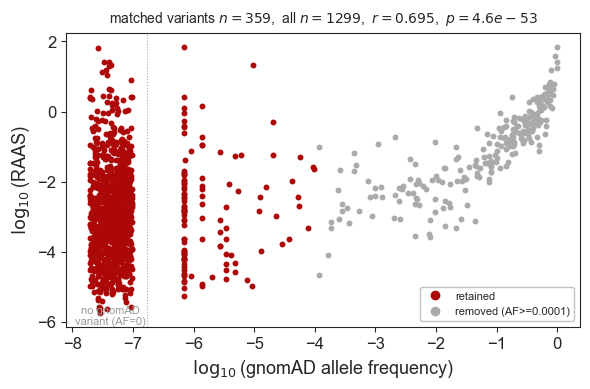

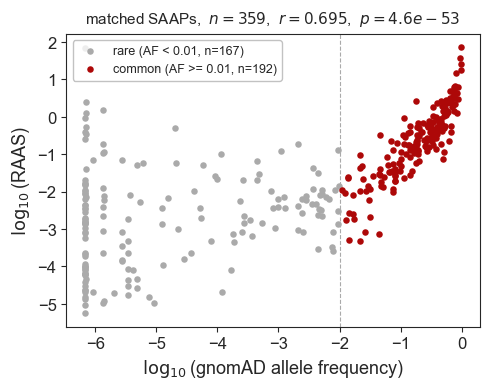

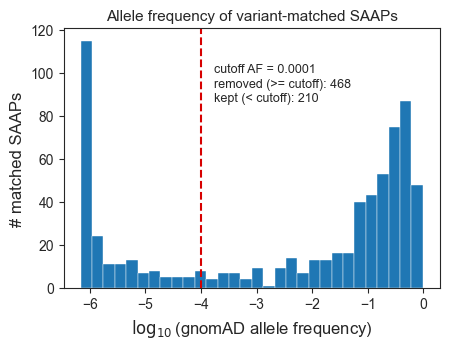

In [15]:
# Append gnomAD outputs to SAAP_quant_df and export to xlsx
gnomad_cols = ['gnomad_status', 'gene', 'protein', 'protein_pos', 'gnomad_variant',
               'gnomad_af', 'gnomad_ac', 'polymorphic', 'reproduces_saap_sub',
               'exact_mutation', 'consequence']
gnomad_merge = (gnomad_annotated
                .rename(columns={'mtp_seq': 'MTP_seq', 'bp_seq': 'BP_seq'})
                [['MTP_seq', 'BP_seq'] + gnomad_cols]
                .sort_values('gnomad_af', na_position='last')          # keep variant-matched row per SAAP
                .drop_duplicates(['MTP_seq', 'BP_seq'], keep='first'))
SAAP_quant_df = SAAP_quant_df.merge(gnomad_merge, on=['MTP_seq', 'BP_seq'], how='left')
print(SAAP_quant_df)

# Save as Supplemental_Data_2.SAAP_precursor_reporter_quant_gnomAD.xlsx
SAAP_quant_df.to_excel(SUPP_DIR + 'Supplemental_Data_2.SAAP_precursor_reporter_quant_gnomAD.xlsx', sheet_name='Users', index=True)

# gnomAD allele frequency filter
AF_THRESHOLD = 0.0001  # 0.01 = common variants filtered out
is_common_variant = SAAP_quant_df['gnomad_af'] >= AF_THRESHOLD
n_rows_before, n_saap_before = len(SAAP_quant_df), SAAP_quant_df['MTP_seq'].nunique()
n_drop = SAAP_quant_df.loc[is_common_variant, 'MTP_seq'].nunique()

SAAP_quant_df_annot = SAAP_quant_df[~is_common_variant].copy()

print(f'AF threshold = {AF_THRESHOLD:g}  (drop SAAPs matching a gnomAD variant with AF >= {AF_THRESHOLD:g})')
print(f'  rows:         {n_rows_before:,} -> {len(SAAP_quant_df_annot):,}')
print(f'  unique SAAPs: {n_saap_before:,} -> '
      f'{SAAP_quant_df_annot["MTP_seq"].nunique():,}  ({n_drop:,} dropped as common variants)')

SAAP_quant_df_annot.to_excel(OUTDIR + f'SAAP_quant_df_AFfiltered_{AF_THRESHOLD:g}.xlsx', index=False)

# Scatter 1 — pooled ACG+FC log10(RAAS) vs log10(gnomAD allele frequency), one point per SAAP.
# Sourced from SAAP_quant_df. ALL SAAPs are shown: variant-matched SAAPs at their real
# allele frequency; SAAPs with no gnomAD variant (no AF) are jittered in a band at the left "AF=0"
# floor so their RAAS still appears. Colored by the AF filter: retained (AF < AF_THRESHOLD)
# -> pink, removed common variant (AF >= AF_THRESHOLD) -> gray. Pearson r/p is over matched SAAPs only.
from matplotlib.lines import Line2D

per = (SAAP_quant_df.replace([np.inf, -np.inf], np.nan)
       .groupby('MTP_seq', as_index=False)
       .agg(mean_RAAS=('Reporter_RAAS', 'mean'), gnomad_af=('gnomad_af', 'max'))
       .dropna(subset=['mean_RAAS']))
per['retained'] = ~(per['gnomad_af'] >= AF_THRESHOLD)               # removed = common variant at/above threshold

matched = per[per['gnomad_af'] > 0].copy()
matched['log_af'] = np.log10(matched['gnomad_af'])
nomatch = per[~(per['gnomad_af'] > 0)].copy()                       # no AF (no matched variant)
floor_x = matched['log_af'].min() - 1.2                             # left "AF = 0" band
nomatch['log_af'] = floor_x + np.random.default_rng(0).uniform(-0.35, 0.35, len(nomatch))

r_val, p_val = sp.stats.pearsonr(matched['log_af'], matched['mean_RAAS'])   # over matched only

fig, ax = plt.subplots(figsize=(6, 4))
for d in (nomatch, matched):
    g, k = d[~d['retained']], d[d['retained']]
    ax.scatter(g['log_af'], g['mean_RAAS'], c='#aaaaaa', s=18, linewidths=0, zorder=2)
    ax.scatter(k['log_af'], k['mean_RAAS'], c="#ad0808", s=18, linewidths=0, zorder=3)
ax.axvline(floor_x + 0.6, color='#aaaaaa', ls=':', lw=0.8)             # separates the no-variant band
ax.annotate('no gnomAD\nvariant (AF=0)', (floor_x, ax.get_ylim()[0]), ha='center', va='bottom',
            fontsize=8, color='0.6')
ax.set_xlabel(r'$\log_{10}$(gnomAD allele frequency)', fontsize=13)
ax.set_ylabel(r'$\log_{10}$(RAAS)', fontsize=13)
ax.tick_params(axis='both', labelsize=12)
ax.text(0.5, 1.02, rf'matched variants $n={len(matched)}$,  all $n={len(per)}$,  $r={r_val:.3f}$,  $p={p_val:.1e}$',
        transform=ax.transAxes, ha='center', va='bottom', fontsize=10)
ax.legend(handles=[Line2D([], [], marker='o', ls='', c='#ad0808', label='retained'),
                   Line2D([], [], marker='o', ls='', c='#aaaaaa', label=f'removed (AF>={AF_THRESHOLD:g})')],
          loc='lower right', frameon=True, facecolor='white', edgecolor='0.7', fontsize=8)
plt.tight_layout()
plt.savefig(PLOT_DIR + 'QC_SAAP_RAAS_vs_gnomAD_AF_scatter.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'QC_SAAP_RAAS_vs_gnomAD_AF_scatter.png', dpi=600, bbox_inches='tight')

# Scatter 2 — same axes, restricted to variant-matched SAAPs, colored by allele-frequency class:
# pink = common variant (AF >= AF_COMMON), gray = rare (AF < AF_COMMON). Works on the current data
# (all matched SAAPs already carry an allele frequency).
AF_COMMON = 0.01   # common-vs-rare allele-frequency cutoff

raas_per_saap = (SAAP_quant_df.replace([np.inf, -np.inf], np.nan)
                 .groupby('MTP_seq', as_index=False)['Reporter_RAAS'].mean()
                 .rename(columns={'Reporter_RAAS': 'mean_RAAS'}))
m = (gnomad_annotated.loc[gnomad_annotated['gnomad_af'] > 0, ['mtp_seq', 'gnomad_af']]
     .rename(columns={'mtp_seq': 'MTP_seq'})
     .drop_duplicates('MTP_seq')
     .merge(raas_per_saap, on='MTP_seq', how='inner')
     .dropna(subset=['gnomad_af', 'mean_RAAS']))
m['log_af'] = np.log10(m['gnomad_af'])
m['common'] = m['gnomad_af'] >= AF_COMMON

x, y = m['log_af'].to_numpy(), m['mean_RAAS'].to_numpy()
r_val, p_val = sp.stats.pearsonr(x, y); n_val = len(x)

fig, ax = plt.subplots(figsize=(5, 4))
rare, common = m[~m['common']], m[m['common']]
ax.scatter(rare['log_af'], rare['mean_RAAS'], c='#aaaaaa', s=22, linewidths=0, zorder=2,
           label=f'rare (AF < {AF_COMMON:g}, n={len(rare)})')
ax.scatter(common['log_af'], common['mean_RAAS'], c='#ad0808', s=22, linewidths=0, zorder=3,
           label=f'common (AF >= {AF_COMMON:g}, n={len(common)})')
ax.axvline(np.log10(AF_COMMON), color='#aaaaaa', ls='--', lw=0.8)
ax.set_xlabel(r'$\log_{10}$(gnomAD allele frequency)', fontsize=13)
ax.set_ylabel(r'$\log_{10}$(RAAS)', fontsize=13)
ax.tick_params(axis='both', labelsize=12)
ax.text(0.5, 1.02, rf'matched SAAPs,  $n={n_val}$,  $r={r_val:.3f}$,  $p={p_val:.1e}$',
        transform=ax.transAxes, ha='center', va='bottom', fontsize=11)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='0.7', fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_DIR + 'QC_SAAP_RAAS_vs_gnomAD_AF_scatter_byAFclass.pdf', bbox_inches='tight'); plt.show()

af = gnomad_annotated.loc[gnomad_annotated['gnomad_af'] > 0, 'gnomad_af'].dropna()
fig, ax = plt.subplots(figsize=(4.6, 3.6))
ax.hist(np.log10(af), bins=30, color=colors[0], edgecolor='white', linewidth=0.3)
ax.axvline(np.log10(AF_THRESHOLD), ls='--', color="#D70000", lw=1.5)
n_rm = int((af >= AF_THRESHOLD).sum())
ax.annotate(f'cutoff AF = {AF_THRESHOLD:g}\nremoved (>= cutoff): {n_rm}\nkept (< cutoff): {len(af) - n_rm}',
            (0.4, 0.72), xycoords='axes fraction', fontsize=9)
ax.set_xlabel(r'$\log_{10}$(gnomAD allele frequency)', fontsize=12); ax.set_ylabel('# matched SAAPs', fontsize=12)
ax.set_title('Allele frequency of variant-matched SAAPs', fontsize=11)
plt.tight_layout(); plt.savefig(PLOT_DIR + 'QC_gnomAD_AF_distribution.pdf', bbox_inches='tight'); plt.show()

In [16]:
# Make sure gnomAD filtering has been applied
removed = len(SAAP_quant_df_annot) - len(SAAP_quant_df)
print(removed)
SAAP_quant_df = SAAP_quant_df_annot 

-3760


In [17]:
print(SAAP_quant_df['MTP_seq'].nunique())

1144


In [18]:
# Save as Supplemental_Data_1.SAAP_quantification_aging_clustered.xlsx
SAAP_quant_df.to_excel(SUPP_DIR+'Supplemental_Data.SAAP_quantification_neurodegen_clustered.xlsx')

# Visualize Validation Metrics

### Positional probability filtering

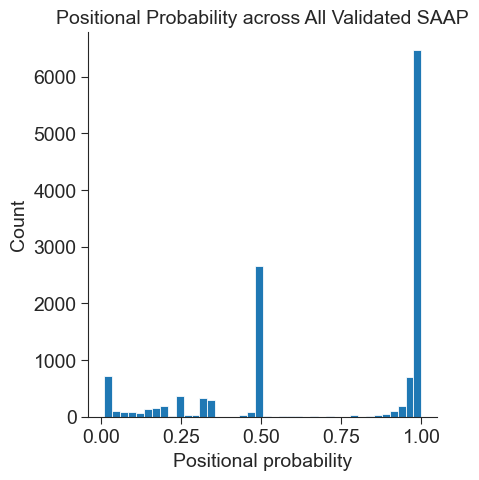

In [18]:
# Filtered distribution 
fig,ax=plt.subplots(figsize=(4.5,5))
sns.set_style(style='ticks')
loc_df=SAAP_quant_df['Positional_probability']
loc_df=(loc_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=loc_df,bins=40,color='#1f78b4',alpha=1)
sns.despine()
ax.tick_params('both',labelsize=14)
plt.xlabel('Positional probability',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.tick_params(axis='both', length=5)
plt.title('Positional Probability across All Validated SAAP',fontsize=14)

plt.savefig(PLOT_DIR+'loc_prob_filt_AAS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'loc_prob_filt_AAS.png',dpi=600,bbox_inches='tight')

### PEP filtering

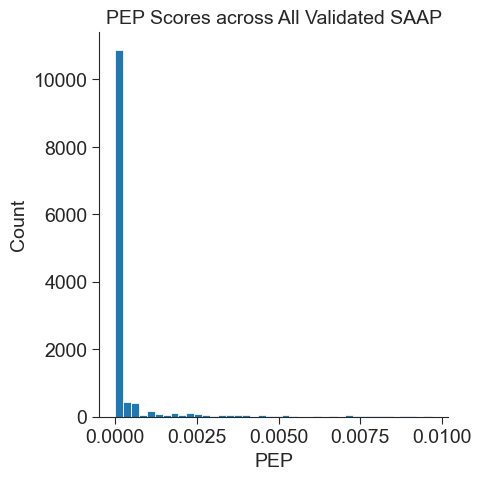

In [19]:
# Plot PEP distribution for all SAAP 
fig,ax=plt.subplots(figsize=(4.5,5))
sns.set_style(style='ticks')
pep_df=SAAP_quant_df['SAAP_PEP']
pep_df=(pep_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=pep_df,bins=40,color='#1f78b4',alpha=1)
sns.despine()
ax.tick_params('both',labelsize=14)
plt.xlabel('PEP',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.tick_params(axis='both', length=5)
plt.title('PEP Scores across All Validated SAAP',fontsize=14)

plt.savefig(PLOT_DIR+'PEP_all_AAS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'PEP_all_AAS.png',dpi=600,bbox_inches='tight')

### Fragment ion support at substitution site

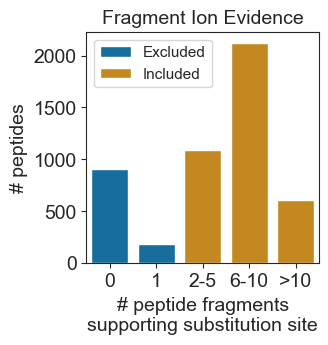

In [20]:
# Fragment ion support at substitution site 
fig,ax=plt.subplots(figsize=(3,3))
plot_df = frag_df
sns.set_style('ticks')
sns.barplot(data=plot_df, x='Bin', y='Count', hue='Used', dodge=False, palette='colorblind')
ax.tick_params('both', labelsize=14)

plt.ylabel('# peptides', fontsize=14)
sns.set_style(style='ticks')
handles, labels = ax.get_legend_handles_labels()
plt.title(f'Fragment Ion Evidence',fontsize=14)
plt.legend(handles=handles, loc='upper left', labels=['Excluded', 'Included'], fontsize=11)
plt.xlabel('# peptide fragments\nsupporting substitution site', fontsize=14)

plt.savefig(PLOT_DIR + 'fragment_ion_evidence_barplot_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'fragment_ion_evidence_barplot_allDS.png',dpi=600,bbox_inches='tight')

In [21]:
# function to get number of peptides in each filtration category 

def get_filter_df(data_dir, samples):
    """ 
    function that reads in output from decode pipeline to get number of peptides in each category
    Input: directory with output files for dataset, dataset samples/TMT set names
    output: dataframe with the number of peptides in each category
    """
    dp_ev_dict = pickle.load(open(data_dir+'DP_search_evidence_dict.p', 'rb'))
    dp_dict = pickle.load(open(data_dir+'DP_dict.p', 'rb'))
    mtp_dict = pickle.load(open(data_dir+'MTP_dict.p', 'rb'))
    ptm_dict = pickle.load(open(data_dir+'PTM_dict.p', 'rb'))
    hc_mtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb')) # dictionary of putative substitutions that pass FDR correction
    substr_dict = pickle.load(open(data_dir+'genome_substr_dict.p', 'rb'))
    val_mtp_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    
    rows = []
    for s in samples:
        seqs = [[x for y in list(mtp_dict[s]['mistranslated sequence'].values()) for x in y] for s in samples]
        seqs = [x for y in seqs for x in y]
        if 'all_6frame_seqs' in substr_dict.keys():
            homolog_seqs = substr_dict['all_6frame_seqs']
        else:
            homolog_seqs = substr_dict['all_frame6_seqs']
        seqs_hom = [x for x in seqs if x in homolog_seqs]
        
        n_main = len(dp_ev_dict[s]['Raw file'])
        n_dp = len(dp_dict[s]['Raw file'])
        n_ptm = len(ptm_dict[s]['Raw file'])
        n_aas = len(mtp_dict[s]['Raw file'])
        n_nohom = len([i for i,x in mtp_dict[s]['mistranslated sequence'].items() if all(y not in seqs_hom for y in x)])
        n_hc = len([i for i,x in hc_mtp_dict[s]['mistranslated sequence'].items() if all(y not in seqs_hom for y in x)])
        n_val = len(val_mtp_dict[s]['Raw file'])

        rows.append([s, n_main, n_dp, n_ptm, n_aas, n_nohom, n_hc, n_val])
    df = pd.DataFrame(rows, columns=['TMT set', 'Main peptides', 'DP', 'PTM', 'AAS', 'Non-homologous', 'High-confidence', 'Validated'])

    return(df)

<Figure size 600x500 with 0 Axes>

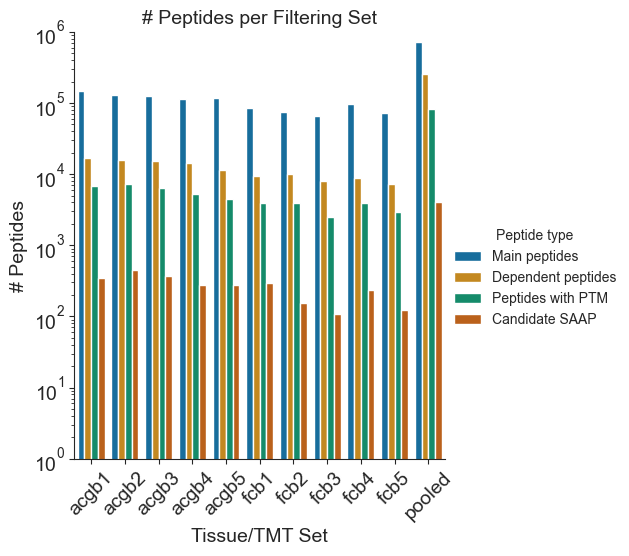

In [22]:
# N peptide IDs through filtering steps for QC figure 

# get number of samples in each dataset
n_samples_data = []
total = 0
for ds in datasets:
    sample_map = sample_map_list[datasets.index(ds)]
    samples = sample_map['sample_name'].values
    
    n_samples = len(samples)
    total += n_samples
    n_samples_data.append([ds, n_samples])

n_samples_df = pd.DataFrame(n_samples_data, columns=['Dataset','N samples'])
# print(n_samples_df)
n_samples_df.to_excel(OUTDIR+'N_samples_in_datasets.xlsx')

# create a dict containing dfs generated above per dataset 
filter_dict = {}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    filter_dict[ds] = get_filter_df(data_dir, samples)

for ds in datasets:
    filter_dict[ds]['Dataset'] = [ds]*len(filter_dict[ds])
pickle.dump(filter_dict, open(OUTDIR+'Modified_peptide_filter_dict_DP2valSAAP.p', 'wb'))
# filter_dict = pickle.load(open(OUTDIR+'Modified_peptide_filter_dict_DP2valSAAP.p', 'rb'))))

all_df = pd.concat([filter_dict[ds] for ds in datasets])

sum_dict = {}
for col in all_df.columns:
    if col not in ['TMT set','Dataset','Tissue']:
        sum_dict[col] = np.nansum(all_df[col].values)
# print(sum_dict)

# filtering modified peptides to candidate SAAP
barplot_rows = []
for i, row in all_df.iterrows():
    barplot_rows.append([row['Dataset'], row['Main peptides'], 'Main peptides', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['DP'], 'Dependent peptides', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['PTM'], 'Peptides with PTM', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['High-confidence'], 'Candidate SAAP', row['TMT set']])
barplot_df = pd.DataFrame(barplot_rows, columns=['Dataset', 'N peptide IDs', 'Peptide type', 'TMT set'])

# plotting 
plt.figure(figsize=(6,5))
sns.set_style(style='ticks')
ax = sns.catplot(data=barplot_df,kind='bar',
                 x='Dataset',y='N peptide IDs',
                 hue='Peptide type',palette='colorblind',
                 alpha=1)

ax.set(yscale='log', ylim=(1, 1e6))
ax.set_axis_labels('Tissue/TMT Set', '# Peptides',fontsize=14)
for ax in ax.axes.flat:
    ax.set_ylabel('# Peptides', fontsize=14)
    ax.tick_params(axis='x',rotation=45,labelsize=14)
    ax.tick_params(axis='y',labelsize=14)
    ax.set_title('# Peptides per Filtering Set',fontsize=14)

plt.savefig(PLOT_DIR+'Dataset_filtering_barplot.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Dataset_filtering_barplot.png',dpi=600,bbox_inches='tight')

In [23]:
#filter_dict = pickle.load(open(outdir+'Modified_peptide_filter_dict_DP2valSAAP.p', 'rb'))
all_df = pd.concat([filter_dict[ds] for ds in datasets])

sum_dict = {}
for col in all_df.columns:
    if col not in ['TMT set', 'Dataset', 'Tissue']:
        sum_dict[col] = np.nansum(all_df[col].values)
        
print(sum_dict) # these values are used in 1a

{'Main peptides': np.int64(1736318), 'DP': np.int64(370236), 'PTM': np.int64(130475), 'AAS': np.int64(7293), 'Non-homologous': np.int64(7293), 'High-confidence': np.int64(6705), 'Validated': np.int64(3882)}


In [24]:
# functions to get number of unique candidate substituted peptides and number of unique validated substituted peptides for each sample in each dataset
def get_n_unq_seqs(data_dir, s):
    """ input: dataset directory, sample
        output: number of unique candidate substituted peptides
    """
    hc_mtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb'))
    s_seqs = [x for y in hc_mtp_dict[s]['mistranslated sequence'].values() for x in y]
    s_seqs = list(set(s_seqs))
    n_seqs = len(s_seqs)
    return(n_seqs)

def get_n_unq_val(data_dir, s):
    """ input: dataset directory, sample
        output: number of unique validated substituted peptides
    """
    val_mtp_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p', 'rb'))
    s_seqs = list(val_mtp_dict[s]['mistranslated sequence'].values())
    s_seqs = list(set(s_seqs))
    n_seqs = len(s_seqs)
    return(n_seqs)

acgb1
acgb2
acgb3
acgb4
acgb5
fcb1
fcb2
fcb3
fcb4
fcb5
pooled


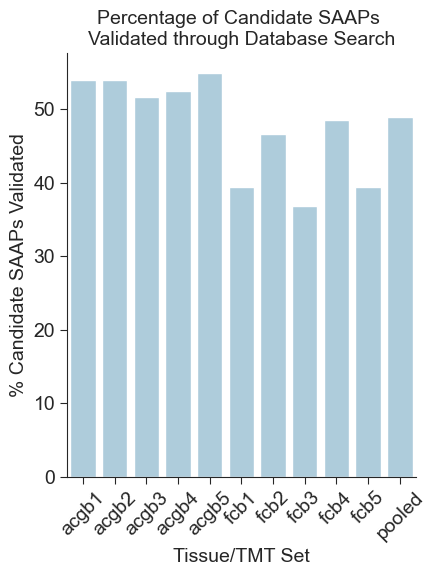

In [25]:
# Percentage of candidate SAAPs validated through database search 

# get dataframe with number of unique substituted peptides, candidate and validated
rows = []
cols = ['Dataset', 'N SAAP sequences', 'SAAP sequence type', 'TMT set']

for i,ds in enumerate(datasets):
    samples=samples_list[i]
    data_dir=data_dir_list[i]
    for s in samples:
        n_seqs = get_n_unq_seqs(data_dir,s)
        n_val_seqs = get_n_unq_val(data_dir,s)
        rows.append([ds,n_seqs,'Candidate',s])
        rows.append([ds,n_val_seqs,'Validated',s])
plt_df = pd.DataFrame(rows,columns=cols)

# get dataframe with percentage of peptides validated and percentage of peptides with no genome homology (from ds_filter_dict.p generated above)
pcnt_rows = []
for i,ds in enumerate(datasets):
    print(ds)
    data_dir = data_dir_list[i]
    samples = samples_list[i]
    ds_plt_df = plt_df.loc[plt_df['Dataset']==ds,:]
    ds_filter_dict = filter_dict[ds]
    for j,s in enumerate(samples):
        s_df = ds_plt_df.loc[ds_plt_df['TMT set']==s,:]
        n_cand = s_df.loc[s_df['SAAP sequence type']=='Candidate', 'N SAAP sequences'].values[0]
        n_val = s_df.loc[s_df['SAAP sequence type']=='Validated', 'N SAAP sequences'].values[0]
        val_pcnt = 100*(n_val/n_cand)
        n_aas = ds_filter_dict['AAS'][j]
        pcnt_rows.append([ds,s, val_pcnt, 'Validated SAAP'])
pcnt_df = pd.DataFrame(pcnt_rows, columns=['Dataset', 'TMT set', '% peptides', '% type'])
nonrectum_row = [i for i,row in pcnt_df.iterrows() if (row['TMT set']!='rectum') and (row['TMT set']!='bonemarrow')] # too little data, removed these tissues from analysis
pcnt_df = pcnt_df.loc[nonrectum_row]
pcnt_df.to_excel(DEPDIR+'percent_validated_genomehomol_SAAP.xlsx')
avg_pcnt_df = pcnt_df.groupby(['Dataset', 'TMT set', '% type'], as_index=False).agg({'% peptides': 'mean'})
# pcnt_df = pd.read_excel(DEPDIR+'percent_validated_genomehomol_SAAP.xlsx', index_col=0)

# plot percentage of candidate SAAPs validated across samples
sns.set_style(style='ticks')
fix,ax = plt.subplots(figsize=(4.5,5.5))
sns.barplot(data=avg_pcnt_df,x='Dataset',
            y='% peptides',hue='% type',
            palette='Paired')
ax.get_legend().remove()
sns.despine()
plt.yticks(fontsize=14)
plt.xticks(rotation=45,fontsize=14)
plt.tick_params(axis='both',length=5)
plt.xlabel('Tissue/TMT Set',fontsize=14)
plt.title('Percentage of Candidate SAAPs \nValidated through Database Search',fontsize=14)
plt.ylabel('% Candidate SAAPs Validated',fontsize=14)

plt.savefig(PLOT_DIR+'Percent_validated_allDS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Percent_validated_allDS.png',dpi=600,bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_74999/1426888465.py:15: RuntimeWarning: divide by zero encountered in log10
  plot_df['-log q'] = plot_df.apply(lambda x: -np.log10(x['q-value']),axis=1)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_74999/1426888465.py:16: RuntimeWarning: divide by zero encountered in log10
  plot_df['-log PEP'] = plot_df.apply(lambda x: -np.log10(x['PEP']),axis=1)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_74999/1426888465.py:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.ecdfplot(plot_df, x='-log q', label='log$_{10}$(q)', palette='colorblind')
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_74999/1426888465.py:20: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.ecdfplot(plot_df, x='-log PEP', label='log$_{10}$(PEP)', palette='colorblind')


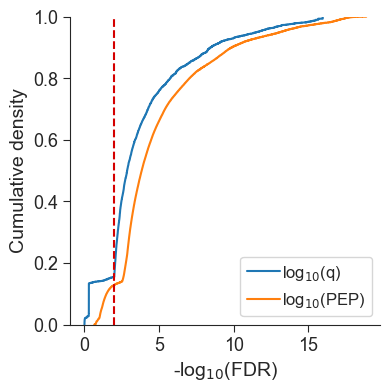

In [26]:
# cumulative density of q-values and PEPs across all datasets and samples
# plot the p-values determined by MaxQuant and the q-values determined from only the substituted peptides
plot_rows = []
plot_cols = ['Dataset', 'TMT/Tissue', 'q-value', 'PEP']
for ds in datasets:
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    qmtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb'))
    for s in samples:
        s_dict = qmtp_dict[s]
        for k,v in s_dict['Posterior subs probability'].items():
            plot_rows.append([ds, s, 1-v[0], s_dict['q-value'][k][0]])
plot_df = pd.DataFrame(plot_rows, columns=plot_cols)

plot_df['-log q'] = plot_df.apply(lambda x: -np.log10(x['q-value']),axis=1)
plot_df['-log PEP'] = plot_df.apply(lambda x: -np.log10(x['PEP']),axis=1)
fig,ax = plt.subplots(figsize=(4,4))
sns.set_style(style='ticks')
sns.ecdfplot(plot_df, x='-log q', label='log$_{10}$(q)', palette='colorblind')
sns.ecdfplot(plot_df, x='-log PEP', label='log$_{10}$(PEP)', palette='colorblind')
plt.ylabel('Cumulative density', fontsize=14)
plt.xlabel('-log$_{10}$(FDR)', fontsize=14)
ax.tick_params('both', labelsize=13)
sns.despine()
plt.plot((2, 2), plt.ylim(), '--', color="#d40000")
plt.tick_params(axis='both', length=5)
plt.legend(loc='lower right', fontsize=12, handletextpad=0.1)

plt.savefig(PLOT_DIR+'qvalue_CumDensity_plot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'qvalue_CumDensity_plot.png',dpi=600, bbox_inches='tight')

<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:58: SyntaxWarning: invalid escape sequence '\g'
<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:58: SyntaxWarning: invalid escape sequence '\g'
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_74999/2872710814.py:35: SyntaxWarning: invalid escape sequence '\g'
  all_ds_plot_df['RAAS group'] = ['$\geq$0' if raas>=0 else '<0' for i,raas in list(enumerate(all_ds_plot_df['Precursor RAAS'].values))]
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_74999/2872710814.py:43: SyntaxWarning: invalid escape sequence '\g'
  sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='-log q', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_74999/2872710814.py:58: SyntaxWarning: invalid escape sequence '\g'
  sns.kdeplot(data = hi

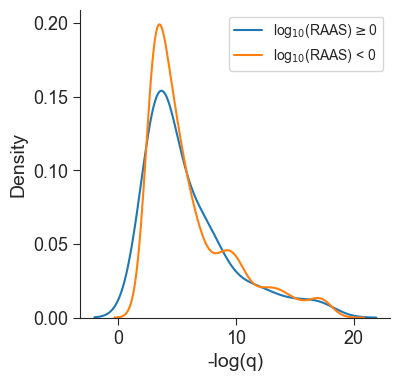

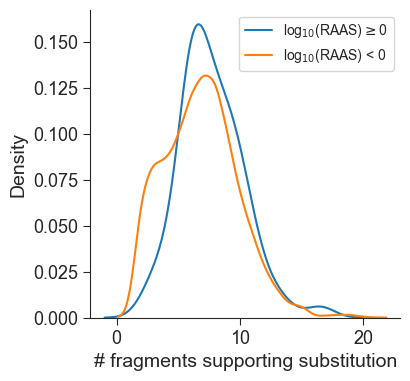

In [27]:
# cumulative density of q-values and PEPs across all datasets and samples stratified by RAAS
# generate a dictionary with PEP values and N fragments for all SAAP in all datasets 
paas_pep_dict = {}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    mtp_dict = pickle.load(open(data_dir + 'Ion_validated_MTP_dict.p', 'rb'))
    mtp_quant_dict = pickle.load(open(data_dir + 'MTP_quant_dict.p', 'rb'))

    plot_rows = []
    plot_cols = ['Dataset', 'Sample', 'SAAP', 'SAAP_val_idx', 'DP PEP', 'SAAP PEP', 'SAAP q', 'SAAP Precursor Intensity','BP Precursor Intensity', 'Precursor RAAS', 'N fragments']
    for s in samples:
        s_dict = mtp_dict[s]
        for k, paas in s_dict['mistranslated sequence'].items():
            paas_pep = s_dict['Posterior subs probability'][k]
            paas_q = s_dict['q-value'][k]
            dp_pep = s_dict['DP PEP'][k]
            n_frags = s_dict['fragment_evidence'][k]
            q_dict = [i for i,v in mtp_quant_dict.items() if v['MTP_seq']==paas]
            if len(q_dict)>0:
                q_dict = mtp_quant_dict[q_dict[0]]
                paas_prec = q_dict['MTP_PrecInt'][s]
                bp_prec = q_dict['BP_PrecInt'][s]
                raas = q_dict['Prec_ratio'][s]
                if (~np.isnan(raas)) and (~np.isinf(raas)):
                    plot_rows.append([ds, s, paas, k, dp_pep, paas_pep, paas_q, paas_prec, bp_prec, raas, n_frags])
    plot_df = pd.DataFrame(plot_rows, columns=plot_cols)   
    paas_pep_dict[ds] = plot_df

pickle.dump(paas_pep_dict, open(OUTDIR+'SAAP_PEP_dfs.p', 'wb'))

# create data frame for plot 
all_ds_plot_df = pd.concat([v for k,v in paas_pep_dict.items()])
all_ds_plot_df['RAAS group'] = ['$\geq$0' if raas>=0 else '<0' for i,raas in list(enumerate(all_ds_plot_df['Precursor RAAS'].values))]
all_ds_plot_df = all_ds_plot_df.loc[all_ds_plot_df['SAAP q']<=0.01]

# plot histogram of confidence values stratified by RAAS
fig,ax = plt.subplots(figsize=(4,4))
all_ds_plot_df['-log q'] = [-np.log10(x) for x in all_ds_plot_df['SAAP q']]
high_raas_df = all_ds_plot_df.loc[all_ds_plot_df['Precursor RAAS']>=0]
low_raas_df = all_ds_plot_df.loc[all_ds_plot_df['Precursor RAAS']<0]
sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='-log q', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
sns.kdeplot(data = low_raas_df.loc[~np.isinf(low_raas_df['-log q'])], x='-log q', fill=False, label='log$_{10}$(RAAS) < 0', palette='colorblind')
sns.despine()
ax.tick_params('both', labelsize=13)
plt.ylabel('Density', fontsize=14)
plt.xlabel('-log(q)', fontsize=14)
plt.legend(fontsize=10)
plt.tick_params(axis='both', length=5)

plt.savefig(PLOT_DIR+'RAASgroup_logq_hist.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'RAASgroup_logq_hist.png', dpi=600, bbox_inches='tight')


# plot histogram of N fragments on substitution site stratified by RAAS
fig,ax = plt.subplots(figsize=(4,4))
sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='N fragments', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
sns.kdeplot(data = low_raas_df.loc[~np.isinf(low_raas_df['-log q'])], x='N fragments', fill=False, label='log$_{10}$(RAAS) < 0', palette='colorblind')
sns.despine()
ax.tick_params('both', labelsize=13)
plt.ylabel('Density', fontsize=14)
plt.xlabel('# fragments supporting substitution', fontsize=14)
# plt.yticks([0,0.03,0.06,0.09,0.12])
plt.tick_params(axis='both', length=5)
plt.legend(loc='upper right', fontsize=10)

plt.savefig(PLOT_DIR+'RAASgroup_Nfrags_hist.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'RAASgroup_Nfrags_hist.png',dpi=600, bbox_inches='tight')

In [28]:
print(SAAP_quant_df['MTP_seq'].nunique())
SAAP_quant_df_filtered = SAAP_quant_df

1144


In [29]:
# Function to find median mass error for a SAAP
def saap_mass_error(saap, s_saap_dict):
    """Median aa-substitution mass error (ppm) for a SAAP; NaN if the SAAP is absent."""
    saap_idx = [k for k, v in s_saap_dict['mistranslated sequence'].items() if v == saap]
    if not saap_idx:
        print(f"WARNING: SAAP {saap} not found in mistranslated sequence")
        return np.nan
    return np.median([s_saap_dict['aa subs mass error (ppm)'][k] for k in saap_idx])

acgb1 S1 rows: 632
       MTP_seq  Reporter_RAAS
0  ASSSSLSMDEK      -2.718330
1  ASSSSLSMDEK      -2.662061
2  ASSSSLSMDEK      -2.725577
3  ASSSSLSMDEK      -2.674941
4  ASSSSLSMDEK      -2.670189
High SAAP: ['QVTSTASTFVK', 'QVTSTASTFVK', 'QVTSTASTFVK', 'GPSGPQGPR', 'GPSGPQGPR', 'LAQEGGWGVMVSHR', 'LAQEGGWGVMVSHR', 'LAQEGGWGVMVSHR', 'LAQEGGWGVMVSHR', 'LAQEGGWGVMVSHR', 'LAQEGGWGVMVSHR', 'LAQEGGWGVMVSHR', 'LAQEGGWGVMVSHR', 'FTVGDHSR', 'FTVGDHSR', 'FTVGDHSR', 'FTVGDHSR', 'FTVGDHSR', 'FTVGDHSR', 'FTVGDHSR', 'FTVGDHSR', 'GLTSIVNEK', 'GLTSIVNEK', 'GLTSIVNEK', 'GLTSIVNEK', 'GLTSIVNEK', 'GLTSIVNEK', 'GLTSIVNEK', 'GLTSIVNEK', 'DLTTGYDSSQPNK', 'DLTTGYDSSQPNK', 'DLTTGYDSSQPNK', 'DLTTGYDSSQPNK', 'KLEALLASNDNANK', 'KLEALLASNDNANK', 'KLEALLASNDNANK', 'KLEALLASNDNANK', 'KLEALLASNDNANK', 'ELVDDSLNNVR', 'ELVDDSLNNVR', 'ELVDDSLNNVR', 'ELVDDSLNNVR', 'ELVDDSLNNVR', 'VLMEDDDLYSCVVENPISQGR', 'VLMEDDDLYSCVVENPISQGR', 'VLMEDDDLYSCVVENPISQGR', 'VLMEDDDLYSCVVENPISQGR', 'DSPETEESPAPEPR', 'LLEGEEDR', 'LLEGEEDR',

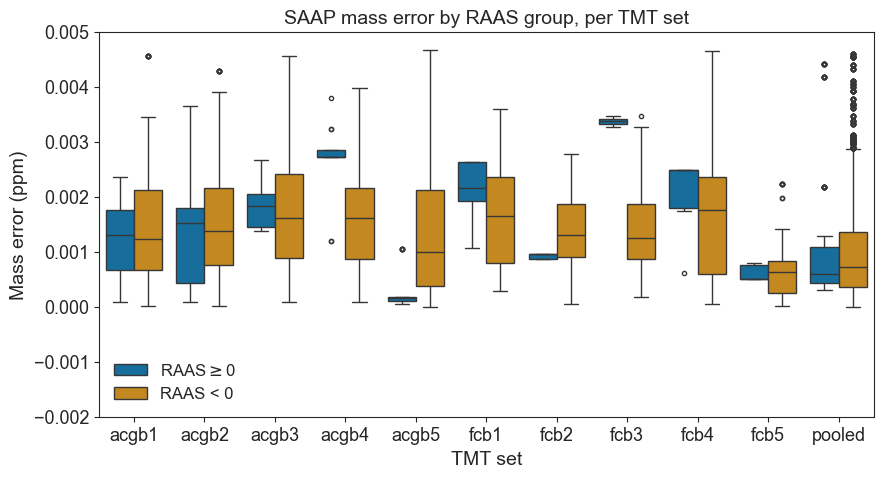

In [30]:
# mass error analysis
SAAP_quant_df['tmt_set'] = SAAP_quant_df['tmt_set'].str.strip("[]'\"")

# create a dictionary with mass errors of SAAP with high and low RAAS
mass_err_dict = {ds:{'High RAAS mass error':[], 'Low RAAS mass error':[]} for ds in datasets}
for ds in datasets:
    data_dir = data_dir_list[datasets.index(ds)]
    ds_prec_df = SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds]   
    saap_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    samples = samples_list[datasets.index(ds)]
    # print(samples)
    for s in samples:
        s_saap_dict = saap_dict[s]
        # print(s_saap_dict.keys())
        if 'aa subs mass error (ppm)' in s_saap_dict.keys():
            s_prec_df = ds_prec_df.loc[ds_prec_df['tmt_set']==s]
            print(f"{ds} {s} rows: {len(s_prec_df)}")
            print(s_prec_df[['MTP_seq', 'Reporter_RAAS']].head())

            high_saap = s_prec_df.loc[s_prec_df['Reporter_RAAS']>=0, 'MTP_seq'].to_list()
            low_saap = s_prec_df.loc[s_prec_df['Reporter_RAAS']<0, 'MTP_seq'].to_list()
            print(f"High SAAP: {high_saap}")
            print(f"Low SAAP: {low_saap}")

            high_errs = [saap_mass_error(saap, s_saap_dict) for saap in high_saap]
            low_errs = [saap_mass_error(saap, s_saap_dict) for saap in low_saap]
            mass_err_dict[ds]['High RAAS mass error']  = mass_err_dict[ds]['High RAAS mass error'] + high_errs
            mass_err_dict[ds]['Low RAAS mass error']  = mass_err_dict[ds]['Low RAAS mass error'] + low_errs 
pickle.dump(mass_err_dict, open(OUTDIR+'High_v_low_RAAS_mass_error_ppm.p','wb'))

# create dataframe for plot
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    high_errs = ds_me_dict['High RAAS mass error']
    low_errs = ds_me_dict['Low RAAS mass error']
    ds_list = [ds]*len(high_errs+low_errs)
    high_str_list = [r'RAAS$\geq$0']*len(high_errs)
    low_str_list = ['RAAS < 0']*len(low_errs)
    ds_plot_df = pd.DataFrame(zip(ds_list, high_errs+low_errs, high_str_list+low_str_list), columns=['Dataset', 'aa subs mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)

# plot distributions of mass errors for SAAP with high and low RAAS
fig,ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=plot_df, x='Dataset', hue='Peptide type', y='aa subs mass error (ppm)', linewidth=1, fliersize=3, palette='colorblind')
plt.ylabel('Mass error (ppm)', fontsize=14)
ax.tick_params('both', labelsize=13)
plt.xlabel('TMT set',fontsize=14)
plt.ylim(-0.002, 0.005)
plt.legend(loc='lower left', fontsize=12, frameon=False, ncol=1)
plt.title('SAAP mass error by RAAS group, per TMT set', fontsize=14)

plt.savefig(PLOT_DIR+'HighvLow_RAAS_Mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'HighvLow_RAAS_Mass_error_boxplots.png', dpi=600, bbox_inches='tight')

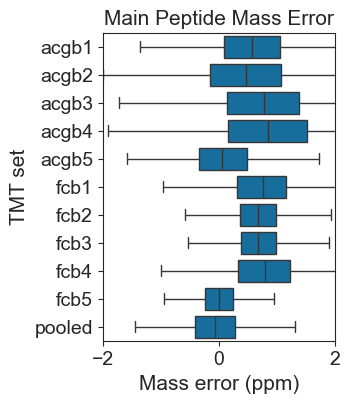

In [31]:
# Main peptide mass error 
# generate a dictionary with mass error data
mass_err_dict = {ds:{'Main peptide mass error':[], 'SAAP mass error':[]} for ds in datasets}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    mainpep_dict = pickle.load(open(data_dir+'DP_search_evidence_dict.p','rb'))
    samples = samples_list[datasets.index(ds)]
    for s in samples:
        errs = mainpep_dict[s]['Mass error [ppm]']
        errs = [x for x in errs if np.abs(x)<10000]
        mass_err_dict[ds]['Main peptide mass error'] = mass_err_dict[ds]['Main peptide mass error']+errs

pickle.dump(mass_err_dict, open(OUTDIR+'Main_peptide_mass_error_ppm.p','wb'))
#mass_err_dict = pickle.load(open(OUTDIR+'Main_peptide_mass_error_ppm.p','rb'))

# plot main peptide mass error boxplots
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    main_pep_errs = ds_me_dict['Main peptide mass error']
    saap_errs = [np.abs(x) for x in ds_me_dict['SAAP mass error']]
    saap_errs = saap_errs + [-x for x in saap_errs]
    ds_list = [ds]*len(main_pep_errs+saap_errs)
    main_str_list = ['Main peptide']*len(main_pep_errs)
    saap_str_list = ['SAAP']*len(saap_errs)

    ds_plot_df = pd.DataFrame(zip(ds_list, main_pep_errs+saap_errs, main_str_list+saap_str_list), columns=['Dataset', 'Mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)

fig,ax = plt.subplots(figsize=(3,4))
sns.boxplot(data=plot_df, y='Dataset', hue='Peptide type', x='Mass error (ppm)', linewidth=1, fliersize=0, palette='colorblind')
plt.xlabel('Mass error (ppm)', fontsize=15)
ax.tick_params('both', labelsize=14)
plt.ylabel('TMT set', fontsize=15)
plt.xlim([-2,2])
plt.title('Main Peptide Mass Error',fontsize=15)
# plt.legend(loc='lower left', fontsize=14, bbox_to_anchor=(-0.2,0.97), frameon=False, ncol=2, handletextpad=0.1, columnspacing=0.8)
ax.get_legend().remove()

plt.savefig(PLOT_DIR+'Mainpep_Mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Mainpep_Mass_error_boxplots.png',dpi=600, bbox_inches='tight')

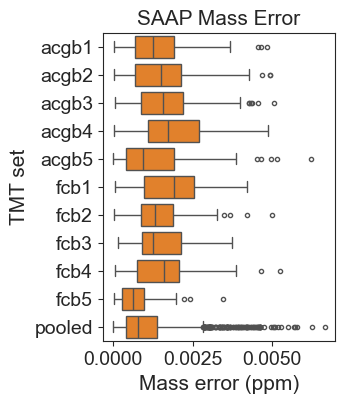

In [32]:
# SAAP mass error 
mass_err_dict = {ds:{'SAAP mass error':[]} for ds in datasets}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    saap_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    samples = samples_list[datasets.index(ds)]
    for s in samples:
        s_saap_dict = saap_dict[s]
        if 'aa subs mass error (ppm)' in s_saap_dict.keys():
            saap_errs = [saap_mass_error(saap, s_saap_dict) for saap in s_saap_dict['mistranslated sequence'].values()]
            mass_err_dict[ds]['SAAP mass error'] = mass_err_dict[ds]['SAAP mass error']+saap_errs
pickle.dump(mass_err_dict, open(OUTDIR+'SAAP_mass_error_ppm.p','wb'))
#mass_err_dict = pickle.load(open(OUTDIR+'SAAP_mass_error_ppm.p','rb'))

# plot SAAP mass error boxplots
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    saap_errs = ds_me_dict['SAAP mass error']
    ds_list = [ds]*len(saap_errs)
    saap_str_list = ['SAAP']*len(saap_errs)

    ds_plot_df = pd.DataFrame(zip(ds_list, saap_errs, saap_str_list), columns=['Dataset', 'Mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)
fig,ax = plt.subplots(figsize=(3,4))
sns.boxplot(data=plot_df, y='Dataset', x='Mass error (ppm)', linewidth=1, fliersize=3, color=colors[1])
plt.xlabel('Mass error (ppm)', fontsize=15)
ax.tick_params('both', labelsize=14)
plt.ylabel('TMT set',fontsize=15)
plt.xscale('linear')
plt.title('SAAP Mass Error',fontsize=15)
# plt.xlim([-0.001,0.0025])

plt.savefig(PLOT_DIR+'SAAP_mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'SAAP_mass_error_boxplots.png', dpi=600,bbox_inches='tight')

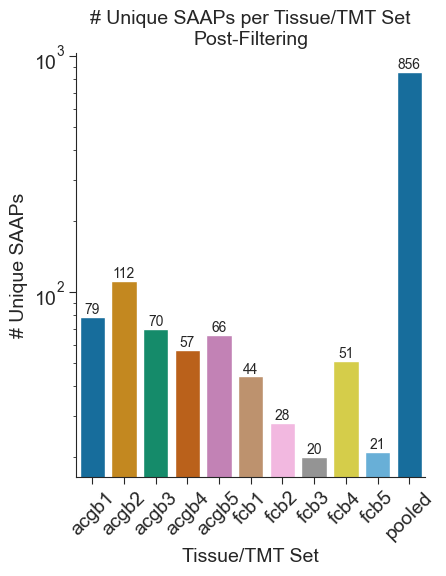

In [33]:
# N SAAPs per dataset post-filtering
plot_rows = []
plot_cols = ['Dataset','N SAAPs']

for ds in datasets:
    ds_df = SAAP_quant_df[SAAP_quant_df['Dataset']==ds]
    n_saaps = ds_df['MTP_seq'].nunique()
    plot_rows.append([ds,n_saaps])

plot_df = pd.DataFrame(plot_rows,columns=plot_cols)
sns.set_style('ticks')

fig,ax = plt.subplots(figsize=(4.5,5.5))
sns.barplot(data=plot_df,x='Dataset',y='N SAAPs',hue='Dataset',palette='colorblind',legend=False)
sns.despine()
plt.tick_params('both',labelsize=14)
plt.xticks(rotation=45)
plt.xlabel('Tissue/TMT Set',fontsize=14)
plt.ylabel('# Unique SAAPs',fontsize=14)
plt.title('# Unique SAAPs per Tissue/TMT Set\nPost-Filtering',fontsize=14)
plt.tick_params(axis='both',length=5)
plt.yscale('log')

for container in ax.containers:
    ax.bar_label(container)

plt.savefig(PLOT_DIR+'N_SAAPs_per_dataset_postfiltering.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'N_SAAPs_per_dataset_postfiltering.png',dpi=600,bbox_inches='tight')

In [34]:
def simplify_dataset(x):
    if x.startswith('acg'):
        return 'ACG'
    elif x.startswith('fc'):
        return 'FC'
    elif x.startswith('pooled'):
        return 'Pooled'
    return x
    

SAAP_quant_df_grouped = SAAP_quant_df.copy()
SAAP_quant_df_grouped['Dataset'] = SAAP_quant_df_grouped['Dataset'].apply(simplify_dataset)

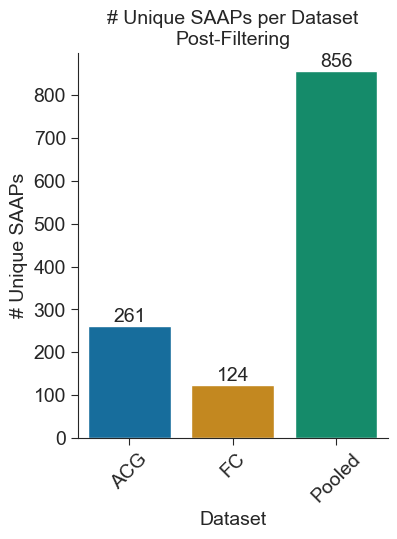

In [35]:
# N SAAPs per dataset post-filtering by brain region 
datasets = ['ACG', 'FC', 'Pooled']
plot_rows = []
plot_cols = ['Dataset','N SAAPs']

for ds in datasets:
    ds_df = SAAP_quant_df_grouped[SAAP_quant_df_grouped['Dataset']==ds]
    n_saaps = ds_df['MTP_seq'].nunique()
    plot_rows.append([ds,n_saaps])

plot_df = pd.DataFrame(plot_rows,columns=plot_cols)
sns.set_style('ticks')

fig,ax = plt.subplots(figsize=(4,5))
sns.barplot(data=plot_df,x='Dataset',y='N SAAPs',hue='Dataset',palette='colorblind',legend=False)
sns.despine()
plt.tick_params('both',labelsize=14)
plt.xticks(rotation=45)
plt.xlabel('Dataset',fontsize=14)
plt.ylabel('# Unique SAAPs',fontsize=14)
plt.title('# Unique SAAPs per Dataset\nPost-Filtering',fontsize=14)
plt.tick_params(axis='both',length=5)

for container in ax.containers:
    ax.bar_label(container, fontsize=14)

plt.savefig(PLOT_DIR+'N_SAAPs_per_dataset_postfiltering_brainregion.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'N_SAAPs_per_dataset_postfiltering_brainregion.png',dpi=600,bbox_inches='tight')


# RAAS

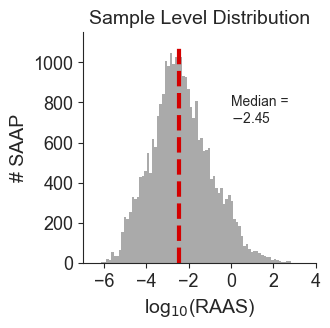

In [36]:
# sample-level RAAS distribution - all datasets in one distribution
sns.set_style('ticks')
fig,ax = plt.subplots(figsize=(3,3))
ratios = []
for i,ds in enumerate(datasets):
    ratio_data = [x for x in SAAP_quant_df_list[i]['Reporter_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    ratios = ratios + ratio_data
sns.histplot(ratios, color='#aaaaaa', bins=80, linewidth=0, alpha=1)
plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--', color='#d40000', linewidth=3)
ax.annotate('Median =\n$-$'+str(np.abs(np.round(np.median(ratios), 2))), (0,700), fontsize=10)
ax.set_ylabel(r'# SAAP', fontsize=14)
ax.set_xlabel(r'log$_{10}$(RAAS)', fontsize=14)
ax.tick_params('both',labelsize=13)
ax.set_title(r'Sample Level Distribution',fontsize=14)
ax.set_xticks([-6,-4,-2,0,2,4]);
sns.despine()

plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_onehistplot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_onehistplot.png',dpi=600, bbox_inches='tight')

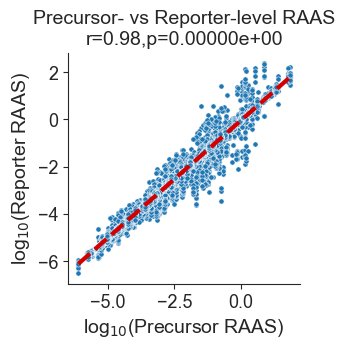

In [37]:
# Precursor vs Reporter RAAS Level Agreeability
fig,ax = plt.subplots(figsize=(3,3))

raas_df=SAAP_quant_df.copy()
raas_df['log10_Prec_RAAS']=raas_df['Prec_RAAS'].replace([np.inf,-np.inf],np.nan)
raas_df['log10_Reporter_RAAS']=raas_df['Reporter_RAAS'].replace([np.inf,-np.inf],np.nan)
raas_df=raas_df.dropna(subset=['log10_Prec_RAAS','log10_Reporter_RAAS'])

r,p=sp.stats.pearsonr(raas_df['log10_Prec_RAAS'],raas_df['log10_Reporter_RAAS'])
sns.set_style('ticks')
sns.scatterplot(data=raas_df,x='log10_Prec_RAAS',y='log10_Reporter_RAAS',s=14,alpha=1,color=colors[0],edgecolor='white',linewidth=0.36,ax=ax)
sns.regplot(data=raas_df,x='log10_Prec_RAAS',y='log10_Reporter_RAAS',scatter=False,line_kws={'color':'#d40000','linestyle':'--','linewidth':3,'zorder':10},ax=ax)

ax.tick_params('both',labelsize=13)
plt.xlabel('log$_{10}$(Precursor RAAS)',fontsize=14)
plt.ylabel('log$_{10}$(Reporter RAAS)',fontsize=14)
# ax.set_xticks([-4,-2,0,2])
plt.title(f'Precursor- vs Reporter-level RAAS\nr={r:.2f},p={p:.5e}',fontsize=14)
sns.despine()
plt.savefig(PLOT_DIR+'MS1_MS2_RAAS_correlation.pdf',bbox_inches='tight')

In [38]:
# Formatting function for bihistogram plots
def bihist(y1, y2, nbins=30, h=None, color='#aaaaaa'):
    """
    Function used to create violin plots as bihistograms with no smoothing.
    h is an axis handle. If not present, a new figure is created.
    """
    if h is None: h = plt.figure().add_subplot(111)
    ymin = np.floor(np.minimum(min(y1), min(y2)))
    ymax = np.ceil(np.maximum(max(y1), max(y2)))
    bins = np.linspace(ymin, ymax, nbins)
    n1, bins1, patch1 = h.hist(y1, bins, orientation="horizontal", color=color, edgecolor=None, linewidth=0, rwidth=1)
    n2, bins2, patch2 = h.hist(y2, bins, orientation="horizontal", color=color, edgecolor=None, linewidth=0, rwidth=1)
    xmax = 0
    for i in patch1:
        i.set_edgecolor(None)
        width = i.get_width()
        if width > xmax: xmax = width
    xmin = 0
    for i in patch2:
        i.set_edgecolor(None)
        width = i.get_width()
        width = -width
        i.set_width(width)
        if width < xmin: xmin = width
    h.set_xlim(xmin*1.1, xmax*1.1)
    h.figure.canvas.draw()

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_74999/1416690939.py:30: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)


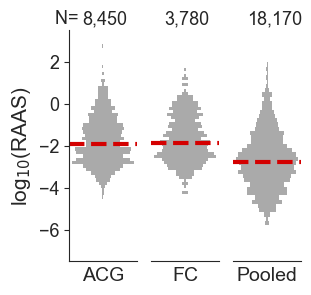

In [39]:
#TMT-level RAAS distribution (precursor ion RAAS distribution), code adapted from Tsour et al 2024
# N = number of quantified SAAP precursor-ion ratios
tissue_order = ['ACG','FC','Pooled']

fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)

sns.set_style('ticks')
sns.despine()
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

medians = [np.nanmedian(SAAP_quant_df_list[i]['Prec_RAAS'].values) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians)) # sort by median instead
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in SAAP_quant_df_list[i]['Prec_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=50,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'TMT_level_RAAS_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'TMT_level_RAAS_allDS.png',dpi=600, bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_74999/3349579470.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)


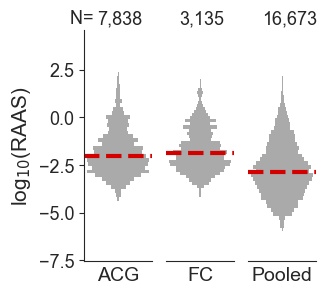

In [40]:
# sample/reporter ion level RAAS distributions for each dataset, code adapted from Tsour et al 2024
# N = number of quantified SAAP reporter-ion ratios

fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)

sns.set_style('ticks')
sns.despine()
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

medians = [np.nanmedian(SAAP_quant_df_list[i]['Reporter_RAAS'].values) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in SAAP_quant_df_list[i]['Reporter_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=50,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_nogrid.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_nogrid.png', dpi=600, bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_74999/487779949.py:16: RuntimeWarning: All-NaN slice encountered
  saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]


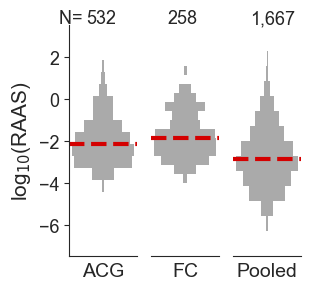

In [41]:
# Median RAAS distributions for all unique SAAP 
fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)
sns.set_style('ticks')
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

saap_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    saap = list(set(reporter_quant_df['MTP_seq'].values))
    saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]
    saap_median_values_list.append(saap_medians)
        
medians = [np.nanmedian(saap_median_values_list[i]) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in saap_median_values_list[i] if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=15,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.15,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.25,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'SAAP_median_RAAS_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'SAAP_median_RAAS_allDS.png', dpi=600, bbox_inches='tight')

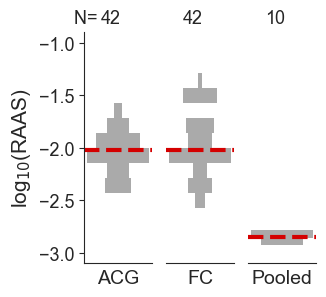

In [42]:
# Sample median RAAS distributions
fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)
sns.set_style('ticks')
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

sample_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    samples = list(set(reporter_quant_df['Sample'].values))
    sample_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['Sample']==s, 'Reporter_RAAS'].values) for s in samples]
    sample_median_values_list.append(sample_medians)
        
medians = [np.nanmedian(sample_median_values_list[i]) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in sample_median_values_list[i] if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=15,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.15,1.04), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.25,1.04), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'Sample_median_RAAS_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Sample_median_RAAS_allDS.png', dpi=600, bbox_inches='tight')

SAAPs in >= 3 tissues: 41


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_74999/2813403896.py:28: RuntimeWarning: All-NaN slice encountered
  saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in shared_saap]


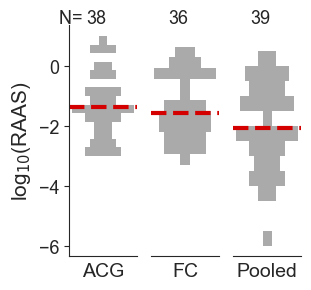

In [43]:
# Median RAAS distributions for SAAPs shared across all tissues, per dataset
fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)
sns.set_style('ticks')
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

# SAAPs (MTP_seq) present in every dataset/tissue
saap_set_list = [set(SAAP_quant_df_list[i]['MTP_seq'].values) for i in range(len(datasets))]
from collections import Counter

MIN_TISSUES = 3 

saap_set_list = [set(SAAP_quant_df_list[i]['MTP_seq'].values) for i in range(len(datasets))]
counts = Counter()
for s in saap_set_list:
    counts.update(s)
shared_saap = {s for s,c in counts.items() if c >= MIN_TISSUES}
print('SAAPs in >= {} tissues: {}'.format(MIN_TISSUES, len(shared_saap)))

saap_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in shared_saap]
    saap_median_values_list.append(saap_medians)
        
medians = [np.nanmedian(saap_median_values_list[i]) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in saap_median_values_list[i] if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=15,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.15,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.25,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'SAAP_median_RAAS_sharedSAAP.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'SAAP_median_RAAS_sharedSAAP.png', dpi=600, bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_74999/3245370680.py:16: RuntimeWarning: All-NaN slice encountered
  saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]


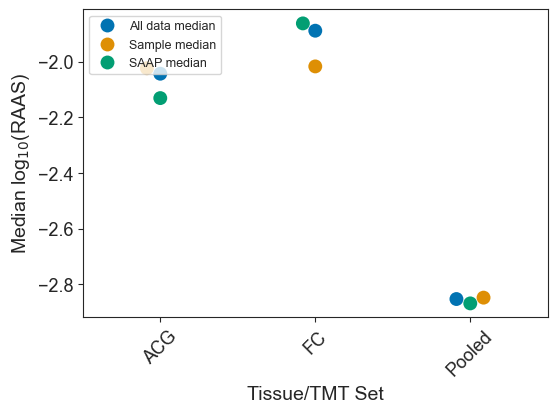

In [44]:
# Medians for all data, sample, and SAAP-level RAAS 
all_medians = [np.nanmedian(SAAP_quant_df_list[i]['Reporter_RAAS'].values) for i in range(len(datasets)-1)]
all_medians.append(np.nanmedian(SAAP_quant_df_list[-1]['Reporter_RAAS'].values))

sample_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    samples = list(set(reporter_quant_df['Sample'].values))
    sample_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['Sample']==s, 'Reporter_RAAS'].values) for s in samples]
    sample_median_values_list.append(sample_medians)

saap_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    saap = list(set(reporter_quant_df['MTP_seq'].values))
    saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]
    saap_median_values_list.append(saap_medians)

sample_medians = [np.nanmedian(sample_median_values_list[i]) for i in range(len(datasets))]
saap_medians = [np.nanmedian(saap_median_values_list[i]) for i in range(len(datasets))]

plot_rows = []
plot_cols = ['Dataset', 'Median RAAS', 'Median type']
for m, median in enumerate(all_medians):
    plot_rows.append([datasets[m], median, 'All data median'])
for m, median in enumerate(sample_medians):
    plot_rows.append([datasets[m], median, 'Sample median'])
for m, median in enumerate(saap_medians):
    plot_rows.append([datasets[m], median, 'SAAP median'])
    
plot_df = pd.DataFrame(plot_rows, columns=plot_cols)    

fig,ax = plt.subplots(figsize=(6,4))
sns.swarmplot(data=plot_df, x='Dataset', y='Median RAAS', hue='Median type', s=10,
              palette='colorblind',order=tissue_order)
plt.legend(loc='upper left',title='', fontsize=9)
ax.tick_params('both', labelsize=13)
plt.xticks(rotation=45)
plt.ylabel('Median log$_{10}$(RAAS)', fontsize=14)
plt.xlabel('Tissue/TMT Set',fontsize=14)

plt.savefig(PLOT_DIR+'RAAS_distribution_median_comparison_swarmplot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'RAAS_distribution_median_comparison_swarmplot.png', dpi=600, bbox_inches='tight')

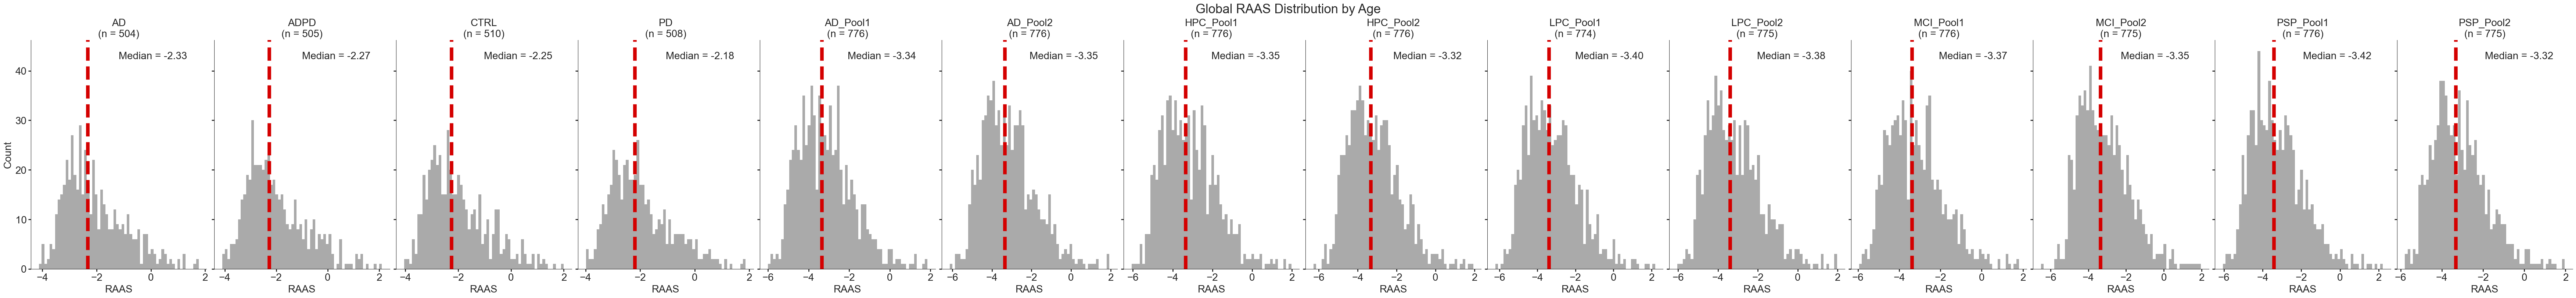

In [45]:
# sample level RAAS distribution by age
# one SAAP RAAS value is the median of its replicates 

age_df = SAAP_quant_df.copy()
age_df = age_df.groupby(['Dataset','MTP_seq','Sample Type'])['Reporter_RAAS'].median().reset_index()
ages = age_df['Sample Type'].unique()
num_ages = len(ages)

fig,axes = plt.subplots(1, num_ages, figsize=(5*num_ages, 8), sharey=True, constrained_layout=True)

for i, age in enumerate(ages):
    ax = axes[i]
    subset = age_df[age_df['Sample Type'] == age]
    vals = subset['Reporter_RAAS'].values
    vals = vals[np.isfinite(vals)] 

    sns.histplot(vals, bins=60, kde=False, ax=ax,
                 color='#aaaaaa', edgecolor=None, linewidth=0,alpha=1)

    median = np.median(vals)
    ax.axvline(median, color='#d40000', linestyle='--', linewidth=7)

    n = len(vals)
    ax.set_title(f'{age}\n(n = {n})', fontsize=20)
    ax.tick_params(axis='both', labelsize=20, length=5, width=2)
    ax.set_xlabel('RAAS', fontsize=20)
    ax.set_ylabel('Count', fontsize=20)
    ax.grid(False)
    sns.despine()

    ax.text(0.5, 0.95, f'Median = {median:.2f}', transform=ax.transAxes,
            fontsize=20, verticalalignment='top')

plt.suptitle('Global RAAS Distribution by Age',fontsize=25)
plt.savefig(PLOT_DIR + 'Global_RAAS_by_age.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'Global_RAAS_by_age.png', dpi=600, bbox_inches='tight')

# Changes with Neurodegenerative State (Ping 2018)

In [75]:
dupe_check = SAAP_quant_df.groupby('MTP_seq')['aa_sub'].nunique()
offenders = dupe_check[dupe_check > 1].index
SAAP_quant_df[SAAP_quant_df['MTP_seq'].isin(offenders)].sort_values('MTP_seq')

,Dataset,MTP_seq,BP_seq,aa_sub,tmt_set,Positional_probability,spectral_entropy,delta_RT,SAAP_PEP,BP_PEP,...,gene,protein,protein_pos,gnomad_variant,gnomad_af,gnomad_ac,polymorphic,reproduces_saap_sub,exact_mutation,consequence
1848,acgb2,ALTVPELTQQMFDGK,ALTVPELTQQMFDAK,A to G,S2,0.973,1.2625,2.5558,0.0003,0.0,...,NaN,ENSP00000451560.1,643.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13865,pooled,ALTVPELTQQMFDGK,ALTVPELTQQMFDSK,S to G,S1,0.499,1.4303,1.8149,0.0000,0.0,...,TUBB2A,ENSP00000369703.2,296.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13866,pooled,ALTVPELTQQMFDGK,ALTVPELTQQMFDSK,S to G,S1,0.499,1.4303,1.8149,0.0000,0.0,...,TUBB2A,ENSP00000369703.2,296.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13867,pooled,ALTVPELTQQMFDGK,ALTVPELTQQMFDSK,S to G,S1,0.499,1.4303,1.8149,0.0000,0.0,...,TUBB2A,ENSP00000369703.2,296.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13868,pooled,ALTVPELTQQMFDGK,ALTVPELTQQMFDSK,S to G,S1,0.499,1.4303,1.8149,0.0000,0.0,...,TUBB2A,ENSP00000369703.2,296.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13869,pooled,ALTVPELTQQMFDGK,ALTVPELTQQMFDSK,S to G,S1,0.499,1.4303,1.8149,0.0000,0.0,...,TUBB2A,ENSP00000369703.2,296.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13870,pooled,ALTVPELTQQMFDGK,ALTVPELTQQMFDSK,S to G,S1,0.499,1.4303,1.8149,0.0000,0.0,...,TUBB2A,ENSP00000369703.2,296.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13871,pooled,ALTVPELTQQMFDGK,ALTVPELTQQMFDSK,S to G,S1,0.499,1.4303,1.8149,0.0000,0.0,...,TUBB2A,ENSP00000369703.2,296.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13872,pooled,ALTVPELTQQMFDGK,ALTVPELTQQMFDSK,S to G,S1,0.499,1.4303,1.8149,0.0000,0.0,...,TUBB2A,ENSP00000369703.2,296.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13873,pooled,ALTVPELTQQMFDGK,ALTVPELTQQMFDSK,S to G,S1,0.499,1.4303,1.8149,0.0000,0.0,...,TUBB2A,ENSP00000369703.2,296.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [95]:
# Prepare a SAAP_quant_df 
print(SAAP_quant_df_filtered)
SAAP_quant_df_Ping = SAAP_quant_df_filtered.copy()

      Dataset         MTP_seq          BP_seq  aa_sub tmt_set  \
0       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
1       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
2       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
3       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
4       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
...       ...             ...             ...     ...     ...   
16709  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
16710  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
16711  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
16712  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
16713  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   

       Positional_probability  spectral_entropy  delta_RT  SAAP_PEP  BP_PEP  \
0                         1.0            1.5401    0.7461       0.0     0.0   
1                         1.0            1.5401    0.7461    

In [96]:
def simplify_sampletype(x):
    if x.startswith('PSP'):
        return 'PSP'
    elif x.startswith('CTRL'):
        return 'Healthy'
    elif x.startswith('AD_Pool'):
        return 'AD_Pool'
    elif x.startswith('LPC'):
        return 'LPC'
    elif x.startswith('MCI'):
        return 'MCI'
    elif x.startswith ('HPC'):
        return 'HPC'
    return x

def simplify_dataset(x):
    if x.startswith('ACG') or x.startswith('acg'):
        return 'Ping'
    elif x.startswith('FC') or x.startswith('fc'):
        return 'Ping'
    elif x.startswith('Pooled ') or x.startswith('pooled'):
        return 'Bai'
    return x

SAAP_quant_df_Ping['Sample Type'] = SAAP_quant_df_Ping['Sample Type'].apply(simplify_sampletype)
print(SAAP_quant_df_Ping['Sample Type'].unique())

['PD' 'Healthy' 'ADPD' 'AD' 'LPC' 'AD_Pool' 'PSP' 'HPC' 'MCI']


In [97]:
# Per-SAAP one-way ANOVA of Reporter_RAAS across neurodegeneration groups.
# For each SAAP we ask whether its RAAS differs across disease states, pooling all Brain datasets.
# A SAAP is tested only if every group has at least min_reps replicates (samples) with a finite RAAS.
from scipy.stats import f_oneway

group_order = ['Healthy', 'AD', 'PD', 'ADPD']
min_reps = 3

# tidy replicate table: one finite Reporter_RAAS per (SAAP, group, sample)
raas_long = SAAP_quant_df_Ping[['MTP_seq', 'Sample Type', 'Sample', 'Reporter_RAAS']].copy()
raas_long['Reporter_RAAS'] = pd.to_numeric(raas_long['Reporter_RAAS'], errors='coerce')
raas_long = raas_long.replace([np.inf, -np.inf], np.nan).dropna(subset=['Reporter_RAAS'])
raas_long = raas_long[raas_long['Sample Type'].isin(group_order)]
raas_long = raas_long.groupby(['MTP_seq', 'Sample Type', 'Sample'], as_index=False)['Reporter_RAAS'].median()

rows = []
for saap, sdf in raas_long.groupby('MTP_seq'):
    by_group = {g: v['Reporter_RAAS'].values for g, v in sdf.groupby('Sample Type')}
    if any(len(by_group.get(g, [])) < min_reps for g in group_order):   # need >= min_reps per group
        continue
    arrays = [by_group[g] for g in group_order]
    f_stat, p = f_oneway(*arrays)
    row = {'MTP_seq': saap, 'n_total': sum(len(a) for a in arrays), 'F': f_stat, 'p_value': p}
    row.update({f'mean_{g}': by_group[g].mean() for g in group_order})
    rows.append(row)

anova_df = pd.DataFrame(rows)
print(f'One-way ANOVA of RAAS across {len(group_order)} groups (>= {min_reps} reps/group): {len(anova_df)} SAAPs tested')
print(anova_df.sort_values('p_value').head(10).to_string(index=False))

One-way ANOVA of RAAS across 4 groups (>= 3 reps/group): 88 SAAPs tested
            MTP_seq  n_total         F  p_value  mean_Healthy   mean_AD   mean_PD  mean_ADPD
    QALQNIIPASTGAAK       24 19.666151 0.000004     -2.874023 -3.198759 -2.267833  -2.621845
          QQVTEAAEK       24 19.041343 0.000004     -3.136926 -3.468495 -2.539623  -2.858439
      QTFATLSELHCDK       24 11.789554 0.000115     -2.495928 -2.777593 -2.001272  -2.290139
FFESFQDLSTPDAVMGNPK       24  8.634729 0.000708     -2.744143 -3.053524 -2.217565  -2.499543
          DQDGTITTK       16  9.795482 0.001510     -2.788269 -3.207445 -2.188378  -2.567413
        QVTSTASTFVK       32  4.624286 0.009483     -1.019929 -0.856550 -0.453212   0.114488
         GVDGQGTLSK       22  5.126524 0.009738     -3.222051 -2.634918 -3.394052  -3.609229
          AEGAPNQGK       39  3.263587 0.032773     -0.558239 -0.715584 -0.629379  -0.625090
         DGGADGTEQR       16  2.549001 0.104790     -2.358143 -2.503688 -2.395798  -2.4748

In [79]:
# Power analysis for the per-SAAP one-way ANOVA: given the effect sizes we actually observe and the
# 4-group design, how many replicates per group are needed to detect a RAAS difference reliably?
from statsmodels.stats.power import FTestAnovaPower

k = len(group_order)
power_alpha, target_power = 0.05, 0.80
analysis = FTestAnovaPower()

# observed effect size per tested SAAP: Cohen's f = sqrt(F * (k-1) / (N-k))
cohens_f = np.sqrt(anova_df['F'] * (k - 1) / (anova_df['n_total'] - k))
cohens_f = cohens_f.replace([np.inf, -np.inf], np.nan).dropna()
f_med = cohens_f.median()

def reps_needed(f):   # replicates/group for target power, rounded up
    return int(np.ceil(analysis.solve_power(effect_size=f, alpha=power_alpha, power=target_power, k_groups=k) / k))

print(f'One-way ANOVA power analysis  (k = {k} groups, alpha = {power_alpha}, target power = {target_power})')
print(f"observed Cohen's f across {len(cohens_f)} tested SAAPs: median {f_med:.2f} "
      f"(IQR {cohens_f.quantile(.25):.2f}-{cohens_f.quantile(.75):.2f})\n")
print('replicates/group needed for 80% power:')
for label, f in [('small  (f=0.10)', 0.10), ('medium (f=0.25)', 0.25), ('large  (f=0.40)', 0.40),
                 (f'observed median (f={f_med:.2f})', f_med)]:
    print(f'  {label:32} n >= {reps_needed(f)}')

print('\npower at the observed median effect for a given replicates/group:')
for n in [3, 5, 8, 10]:
    print(f'  n = {n:>2}/group  ->  power = {analysis.power(effect_size=f_med, nobs=n * k, alpha=power_alpha, k_groups=k):.2f}')

One-way ANOVA power analysis  (k = 4 groups, alpha = 0.05, target power = 0.8)
observed Cohen's f across 88 tested SAAPs: median 0.16 (IQR 0.07-0.32)

replicates/group needed for 80% power:
  small  (f=0.10)                  n >= 274
  medium (f=0.25)                  n >= 45
  large  (f=0.40)                  n >= 19
  observed median (f=0.16)         n >= 104

power at the observed median effect for a given replicates/group:
  n =  3/group  ->  power = 0.06
  n =  5/group  ->  power = 0.08
  n =  8/group  ->  power = 0.10
  n = 10/group  ->  power = 0.11


In [98]:
# Benjamini-Hochberg FDR across the per-SAAP ANOVA p-values (multiplicity family = the SAAPs tested).
alpha = 0.05
anova_df['fdr'] = np.nan
ok = anova_df['p_value'].notna()
anova_df.loc[ok, 'fdr'] = multipletests(anova_df.loc[ok, 'p_value'], method='fdr_bh')[1]
anova_df['significant'] = anova_df['fdr'] <= alpha

print(f"{int(anova_df['significant'].sum())} / {len(anova_df)} SAAPs differ across groups (BH-FDR <= {alpha})")
print(anova_df.loc[anova_df['significant']].sort_values('fdr')[['MTP_seq', 'F', 'p_value', 'fdr']].to_string(index=False))

5 / 88 SAAPs differ across groups (BH-FDR <= 0.05)
            MTP_seq         F  p_value      fdr
    QALQNIIPASTGAAK 19.666151 0.000004 0.000196
          QQVTEAAEK 19.041343 0.000004 0.000196
      QTFATLSELHCDK 11.789554 0.000115 0.003363
FFESFQDLSTPDAVMGNPK  8.634729 0.000708 0.015585
          DQDGTITTK  9.795482 0.001510 0.026579


In [99]:
# Tukey HSD post-hoc on the FDR-significant SAAPs: all pairwise disease-state comparisons per SAAP.
# Tukey's adjusted p already controls the family-wise error across the pairwise tests within a SAAP.
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sig_saaps = anova_df.loc[anova_df['significant'], 'MTP_seq']
rows = []
for saap in sig_saaps:
    sdf = raas_long[raas_long['MTP_seq'] == saap]
    tukey = pairwise_tukeyhsd(sdf['Reporter_RAAS'].values, sdf['Sample Type'].values)
    for g1, g2, meandiff, p_adj, lo, hi, reject in tukey._results_table.data[1:]:
        rows.append({'MTP_seq': saap, 'group1': g1, 'group2': g2,
                     'meandiff': meandiff, 'p_adj': p_adj, 'ci_low': lo, 'ci_high': hi, 'reject': reject})

tukey_df = pd.DataFrame(rows)
n_pairs = int(tukey_df['reject'].sum()) if not tukey_df.empty else 0
print(f'Tukey HSD on {sig_saaps.nunique()} significant SAAPs: {n_pairs} / {len(tukey_df)} pairwise comparisons significant')
if not tukey_df.empty:
    print(tukey_df.loc[tukey_df['reject']].sort_values('p_adj').head(15).to_string(index=False))

Tukey HSD on 5 significant SAAPs: 16 / 30 pairwise comparisons significant
            MTP_seq  group1 group2  meandiff  p_adj  ci_low  ci_high  reject
    QALQNIIPASTGAAK      AD     PD    0.9309 0.0000  0.5794   1.2825    True
          QQVTEAAEK      AD     PD    0.9289 0.0000  0.5697   1.2880    True
      QTFATLSELHCDK      AD     PD    0.7763 0.0001  0.3983   1.1543    True
FFESFQDLSTPDAVMGNPK      AD     PD    0.8360 0.0005  0.3568   1.3151    True
    QALQNIIPASTGAAK Healthy     PD    0.6062 0.0005  0.2547   0.9577    True
          QQVTEAAEK      AD   ADPD    0.6101 0.0006  0.2509   0.9692    True
          QQVTEAAEK Healthy     PD    0.5973 0.0008  0.2382   0.9564    True
          DQDGTITTK      AD     PD    1.0191 0.0009  0.4478   1.5904    True
    QALQNIIPASTGAAK      AD   ADPD    0.5769 0.0009  0.2254   0.9284    True
      QTFATLSELHCDK Healthy     PD    0.4947 0.0077  0.1167   0.8726    True
      QTFATLSELHCDK      AD   ADPD    0.4875 0.0087  0.1095   0.8654    True
F

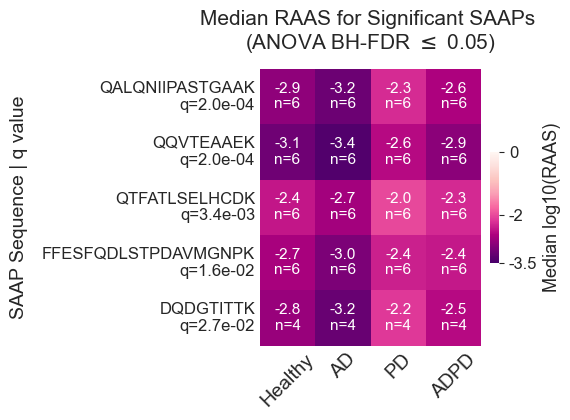

In [82]:
# Heatmap of median Reporter_RAAS per neurodegeneration group for the ANOVA-significant SAAPs.
# Rows = SAAPs (ordered by ANOVA FDR, q-value shown per row); each cell = that SAAP's median RAAS
# RAAS within the group, annotated with the number of samples (n) backing that median.
sig = anova_df.loc[anova_df['significant']].sort_values('fdr')
keep = raas_long[raas_long['MTP_seq'].isin(sig['MTP_seq'])]

med = keep.pivot_table(index='MTP_seq', columns='Sample Type', values='Reporter_RAAS', aggfunc='median').reindex(index=sig['MTP_seq'], columns=group_order)
cnt = keep.pivot_table(index='MTP_seq', columns='Sample Type', values='Reporter_RAAS', aggfunc='count').reindex(index=sig['MTP_seq'], columns=group_order)

# per-cell label: median RAAS over the n samples that carry this SAAP in this group
annot = med.copy().astype('object')
for saap in med.index:
    for grp in med.columns:
        annot.loc[saap, grp] = f"{med.loc[saap, grp]:.1f}\nn={int(cnt.loc[saap, grp])}"

# per-SAAP BH-FDR q-value carried on the row label
q_by_saap = sig.set_index('MTP_seq')['fdr']
ylabels = [f"{saap}\nq={q_by_saap[saap]:.1e}" for saap in med.index]

# color scale spans the actual range of the medians shown so between-group differences are visible;
# the medians here are all negative, so a fixed 0-centered scale would squash them into one shade
# vmin, vmax = np.nanmin(med.values), np.nanmax(med.values)
vmin, vmax = -3.5, 0

sns.set_style('white')
cell = 0.5
fig, ax = plt.subplots(figsize=(len(group_order) * cell + 4, len(med) * cell + 1.8))
sns.heatmap(med, cmap='RdPu_r', vmin=vmin, vmax=vmax,
            annot=annot.values, fmt='', annot_kws={'size': 11, 'linespacing': 1.15},
            linewidths=0, square=True,
            cbar_kws={'label': 'median RAAS', 'shrink': 0.4, 'pad': 0.02, 'aspect': 12},
            ax=ax)

ax.set_xticklabels(group_order, rotation=45, fontsize=14)
ax.set_yticklabels(ylabels, rotation=0, fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('SAAP Sequence | q value', fontsize=14, labelpad=10)
ax.tick_params(length=0)
ax.set_title(f'Median RAAS for Significant SAAPs \n(ANOVA BH-FDR $\\leq$ {alpha})', fontsize=15, pad=14)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Median log10(RAAS)', fontsize=13)
cbar.outline.set_visible(False)
cbar.set_ticks([-3.5, -2, 0])
cbar.set_ticklabels(['-3.5', '-2', '0'])

fig.tight_layout()
plt.savefig(PLOT_DIR + 'RAAS_median_neurodegen_heatmap_PING.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'RAAS_median_neurodegen_heatmap_PING.png', dpi=300, bbox_inches='tight')
plt.show()

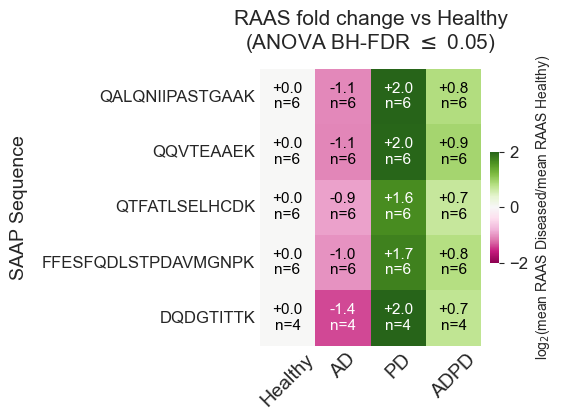

In [101]:
# Heatmap of log2 fold change in RAAS vs Healthy for the ANOVA-significant SAAPs.
# Per SAAP per group: log2FC = (mean RAAS[group] - mean RAAS[Healthy]) * log2(10); Healthy column = 0.
# Cells annotated with the fold change and the number of samples (n) backing each group mean.
sig = anova_df.loc[anova_df['significant']].sort_values('fdr')
keep = raas_long[raas_long['MTP_seq'].isin(sig['MTP_seq'])]

log2fc = pd.DataFrame({g: (sig[f'mean_{g}'] - sig['mean_Healthy']).values * np.log2(10)
                       for g in group_order}, index=sig['MTP_seq'].values)
cnt = keep.pivot_table(index='MTP_seq', columns='Sample Type', values='Reporter_RAAS', aggfunc='count').reindex(index=sig['MTP_seq'], columns=group_order)

annot = log2fc.copy().astype('object')
for saap in log2fc.index:
    for grp in log2fc.columns:
        annot.loc[saap, grp] = f"{log2fc.loc[saap, grp]:+.1f}\nn={int(cnt.loc[saap, grp])}"

q_by_saap = sig.set_index('MTP_seq')['fdr']
ylabels = list(log2fc.index)

# TwoSlopeNorm: an independent slope on each side of 0 keeps 0 white (no change vs Healthy) while
# -4 reaches the darkest blue and +5.3 the darkest red, so both tails saturate instead of washing out
from matplotlib.colors import TwoSlopeNorm
norm = TwoSlopeNorm(vmin=-2, vcenter=0, vmax=2)

sns.set_style('white')
cell = 0.5
fig, ax = plt.subplots(figsize=(len(group_order) * cell + 4, len(log2fc) * cell + 1.8))
sns.heatmap(log2fc, cmap='PiYG',
            annot=annot.values, fmt='', annot_kws={'size': 11, 'linespacing': 1.15},
            linewidths=0, square=True,
            cbar_kws={'label': 'log$_2$ FC vs Healthy', 'shrink': 0.4, 'pad': 0.02, 'aspect': 12},
            ax=ax)

qm = ax.collections[0]
qm.set_norm(norm)
qm.colorbar.update_normal(qm)

# recolor each annotation based on its cell's luminance
cmap_obj = plt.get_cmap('PiYG')
n_rows, n_cols = log2fc.shape
for i in range(n_rows):
    for j in range(n_cols):
        val = log2fc.values[i, j]
        rgba = cmap_obj(norm(val))
        # perceptual luminance
        lum = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
        text_color = 'black' if lum > 0.6 else 'white'
        ax.texts[i * n_cols + j].set_color(text_color)

ax.set_xticklabels(group_order, rotation=45, fontsize=14)
ax.set_yticklabels(ylabels, rotation=0, fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('SAAP Sequence', fontsize=14, labelpad=10)
ax.tick_params(length=0)
ax.set_title(f'RAAS fold change vs Healthy\n(ANOVA BH-FDR $\\leq$ {alpha})', fontsize=15, pad=14)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label('log$_2$(mean RAAS Diseased/mean RAAS Healthy)', fontsize=10)
cbar.outline.set_visible(False)

fig.tight_layout()
plt.savefig(PLOT_DIR + 'RAAS_log2FC_vs_healthy_neurodegen_heatmap_PING.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'RAAS_log2FC_vs_healthy_neurodegen_heatmap_PING.png', dpi=300, bbox_inches='tight')
plt.show()

# Changes with Neurodegenerative State (Ping + Bai Pooled)

In [84]:
# Prepare a SAAP_quant_df 
print(SAAP_quant_df_filtered)
SAAP_quant_df_Pooled = SAAP_quant_df_filtered.copy()

      Dataset         MTP_seq          BP_seq  aa_sub tmt_set  \
0       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
1       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
2       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
3       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
4       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
...       ...             ...             ...     ...     ...   
16709  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
16710  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
16711  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
16712  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
16713  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   

       Positional_probability  spectral_entropy  delta_RT  SAAP_PEP  BP_PEP  \
0                         1.0            1.5401    0.7461       0.0     0.0   
1                         1.0            1.5401    0.7461    

In [85]:
def simplify_sampletype(x):
    if x.startswith('PSP'):
        return 'PSP'
    elif x.startswith('CTRL'):
        return 'Healthy'
    elif x.startswith('AD_Pool'):
        return 'AD'
    elif x.startswith('LPC') or x.startswith('MCI') or x.startswith('HPC'):
        return 'AD'
    return x

def simplify_dataset(x):
    if x.startswith('ACG') or x.startswith('acg'):
        return 'Brain'
    elif x.startswith('FC') or x.startswith('fc'):
        return 'Brain'
    elif x.startswith('Pooled ') or x.startswith('pooled'):
        return 'Brain'
    return x

SAAP_quant_df_Pooled['Sample Type'] = SAAP_quant_df_Pooled['Sample Type'].apply(simplify_sampletype)
print(SAAP_quant_df_Pooled['Sample Type'].unique())

['PD' 'Healthy' 'ADPD' 'AD' 'PSP']


In [86]:
# Per-SAAP one-way ANOVA of Reporter_RAAS across neurodegeneration groups.
# For each SAAP we ask whether its RAAS differs across disease states, pooling all Brain datasets.
# A SAAP is tested only if every group has at least min_reps replicates (samples) with a finite RAAS.
from scipy.stats import f_oneway

group_order = ['Healthy', 'AD', 'PD', 'ADPD']
min_reps = 3

# tidy replicate table: one finite Reporter_RAAS per (SAAP, group, sample)
raas_long = SAAP_quant_df_Pooled[['MTP_seq', 'Sample Type', 'Sample', 'Reporter_RAAS']].copy()
raas_long['Reporter_RAAS'] = pd.to_numeric(raas_long['Reporter_RAAS'], errors='coerce')
raas_long = raas_long.replace([np.inf, -np.inf], np.nan).dropna(subset=['Reporter_RAAS'])
raas_long = raas_long[raas_long['Sample Type'].isin(group_order)]
raas_long = raas_long.groupby(['MTP_seq', 'Sample Type', 'Sample'], as_index=False)['Reporter_RAAS'].median()

rows = []
for saap, sdf in raas_long.groupby('MTP_seq'):
    by_group = {g: v['Reporter_RAAS'].values for g, v in sdf.groupby('Sample Type')}
    if any(len(by_group.get(g, [])) < min_reps for g in group_order):   # need >= min_reps per group
        continue
    arrays = [by_group[g] for g in group_order]
    f_stat, p = f_oneway(*arrays)
    row = {'MTP_seq': saap, 'n_total': sum(len(a) for a in arrays), 'F': f_stat, 'p_value': p}
    row.update({f'mean_{g}': by_group[g].mean() for g in group_order})
    rows.append(row)

anova_df = pd.DataFrame(rows)
print(f'One-way ANOVA of RAAS across {len(group_order)} groups (>= {min_reps} reps/group): {len(anova_df)} SAAPs tested')
print(anova_df.sort_values('p_value').head(10).to_string(index=False))

One-way ANOVA of RAAS across 4 groups (>= 3 reps/group): 88 SAAPs tested
            MTP_seq  n_total         F  p_value  mean_Healthy   mean_AD   mean_PD  mean_ADPD
      QTFATLSELHCDK       32 15.780543 0.000003     -2.495928 -3.543205 -2.001272  -2.290139
    QALQNIIPASTGAAK       24 19.666151 0.000004     -2.874023 -3.198759 -2.267833  -2.621845
          QQVTEAAEK       24 19.041343 0.000004     -3.136926 -3.468495 -2.539623  -2.858439
    VQAHAGEYGAEALER       38  8.891801 0.000173     -2.848941 -3.448520 -2.542161  -2.665830
FFESFQDLSTPDAVMGNPK       24  8.634729 0.000708     -2.744143 -3.053524 -2.217565  -2.499543
          DQDGTITTK       16  9.795482 0.001510     -2.788269 -3.207445 -2.188378  -2.567413
         AQFAGDDAPR       24  6.938533 0.002198     -2.772252 -3.136320 -2.180693  -2.450946
        LEIWDTAGQER       24  6.344269 0.003371     -1.001801 -1.975660 -1.006832  -1.017480
           LLEGEEDR       43  5.164264 0.004210     -0.249552 -0.479402 -0.215848  -0.0534

In [87]:
# Power analysis for the per-SAAP one-way ANOVA: given the effect sizes we actually observe and the
# 4-group design, how many replicates per group are needed to detect a RAAS difference reliably?
from statsmodels.stats.power import FTestAnovaPower

k = len(group_order)
power_alpha, target_power = 0.05, 0.80
analysis = FTestAnovaPower()

# observed effect size per tested SAAP: Cohen's f = sqrt(F * (k-1) / (N-k))
cohens_f = np.sqrt(anova_df['F'] * (k - 1) / (anova_df['n_total'] - k))
cohens_f = cohens_f.replace([np.inf, -np.inf], np.nan).dropna()
f_med = cohens_f.median()

def reps_needed(f):   # replicates/group for target power, rounded up
    return int(np.ceil(analysis.solve_power(effect_size=f, alpha=power_alpha, power=target_power, k_groups=k) / k))

print(f'One-way ANOVA power analysis  (k = {k} groups, alpha = {power_alpha}, target power = {target_power})')
print(f"observed Cohen's f across {len(cohens_f)} tested SAAPs: median {f_med:.2f} "
      f"(IQR {cohens_f.quantile(.25):.2f}-{cohens_f.quantile(.75):.2f})\n")
print('replicates/group needed for 80% power:')
for label, f in [('small  (f=0.10)', 0.10), ('medium (f=0.25)', 0.25), ('large  (f=0.40)', 0.40),
                 (f'observed median (f={f_med:.2f})', f_med)]:
    print(f'  {label:32} n >= {reps_needed(f)}')

print('\npower at the observed median effect for a given replicates/group:')
for n in [3, 5, 8, 10]:
    print(f'  n = {n:>2}/group  ->  power = {analysis.power(effect_size=f_med, nobs=n * k, alpha=power_alpha, k_groups=k):.2f}')

One-way ANOVA power analysis  (k = 4 groups, alpha = 0.05, target power = 0.8)
observed Cohen's f across 88 tested SAAPs: median 0.18 (IQR 0.08-0.41)

replicates/group needed for 80% power:
  small  (f=0.10)                  n >= 274
  medium (f=0.25)                  n >= 45
  large  (f=0.40)                  n >= 19
  observed median (f=0.18)         n >= 82

power at the observed median effect for a given replicates/group:
  n =  3/group  ->  power = 0.07
  n =  5/group  ->  power = 0.08
  n =  8/group  ->  power = 0.11
  n = 10/group  ->  power = 0.13


In [88]:
# Benjamini-Hochberg FDR across the per-SAAP ANOVA p-values (multiplicity family = the SAAPs tested).
alpha = 0.05
anova_df['fdr'] = np.nan
ok = anova_df['p_value'].notna()
anova_df.loc[ok, 'fdr'] = multipletests(anova_df.loc[ok, 'p_value'], method='fdr_bh')[1]
anova_df['significant'] = anova_df['fdr'] <= alpha

print(f"{int(anova_df['significant'].sum())} / {len(anova_df)} SAAPs differ across groups (BH-FDR <= {alpha})")
print(anova_df.loc[anova_df['significant']].sort_values('fdr')[['MTP_seq', 'F', 'p_value', 'fdr']].to_string(index=False))

10 / 88 SAAPs differ across groups (BH-FDR <= 0.05)
            MTP_seq         F  p_value      fdr
    QALQNIIPASTGAAK 19.666151 0.000004 0.000130
          QQVTEAAEK 19.041343 0.000004 0.000130
      QTFATLSELHCDK 15.780543 0.000003 0.000130
    VQAHAGEYGAEALER  8.891801 0.000173 0.003799
FFESFQDLSTPDAVMGNPK  8.634729 0.000708 0.012468
          DQDGTITTK  9.795482 0.001510 0.022149
         AQFAGDDAPR  6.938533 0.002198 0.027627
        LEIWDTAGQER  6.344269 0.003371 0.037080
           LLEGEEDR  5.164264 0.004210 0.041169
          SAVTALSGK  5.806733 0.005423 0.047721


In [89]:
# Tukey HSD post-hoc on the FDR-significant SAAPs: all pairwise disease-state comparisons per SAAP.
# Tukey's adjusted p already controls the family-wise error across the pairwise tests within a SAAP.
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sig_saaps = anova_df.loc[anova_df['significant'], 'MTP_seq']
rows = []
for saap in sig_saaps:
    sdf = raas_long[raas_long['MTP_seq'] == saap]
    tukey = pairwise_tukeyhsd(sdf['Reporter_RAAS'].values, sdf['Sample Type'].values)
    for g1, g2, meandiff, p_adj, lo, hi, reject in tukey._results_table.data[1:]:
        rows.append({'MTP_seq': saap, 'group1': g1, 'group2': g2,
                     'meandiff': meandiff, 'p_adj': p_adj, 'ci_low': lo, 'ci_high': hi, 'reject': reject})

tukey_df = pd.DataFrame(rows)
n_pairs = int(tukey_df['reject'].sum()) if not tukey_df.empty else 0
print(f'Tukey HSD on {sig_saaps.nunique()} significant SAAPs: {n_pairs} / {len(tukey_df)} pairwise comparisons significant')
if not tukey_df.empty:
    print(tukey_df.loc[tukey_df['reject']].sort_values('p_adj').head(15).to_string(index=False))

Tukey HSD on 10 significant SAAPs: 27 / 60 pairwise comparisons significant
            MTP_seq  group1  group2  meandiff  p_adj  ci_low  ci_high  reject
    QALQNIIPASTGAAK      AD      PD    0.9309 0.0000  0.5794   1.2825    True
      QTFATLSELHCDK      AD      PD    1.5419 0.0000  0.8263   2.2575    True
          QQVTEAAEK      AD      PD    0.9289 0.0000  0.5697   1.2880    True
      QTFATLSELHCDK      AD    ADPD    1.2531 0.0003  0.5375   1.9687    True
    VQAHAGEYGAEALER      AD      PD    0.9064 0.0003  0.3740   1.4387    True
    QALQNIIPASTGAAK Healthy      PD    0.6062 0.0005  0.2547   0.9577    True
FFESFQDLSTPDAVMGNPK      AD      PD    0.8360 0.0005  0.3568   1.3151    True
          QQVTEAAEK      AD    ADPD    0.6101 0.0006  0.2509   0.9692    True
          QQVTEAAEK Healthy      PD    0.5973 0.0008  0.2382   0.9564    True
    QALQNIIPASTGAAK      AD    ADPD    0.5769 0.0009  0.2254   0.9284    True
          DQDGTITTK      AD      PD    1.0191 0.0009  0.4478   1.5

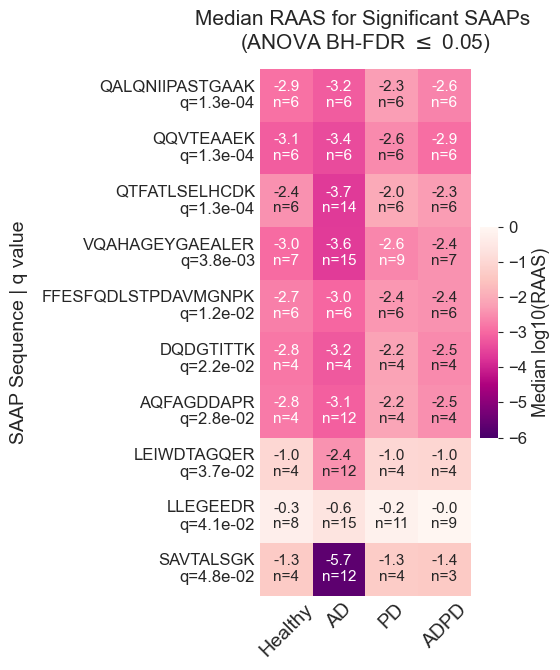

In [90]:
# Heatmap of median Reporter_RAAS per neurodegeneration group for the ANOVA-significant SAAPs.
# Rows = SAAPs (ordered by ANOVA FDR, q-value shown per row); each cell = that SAAP's median RAAS
# RAAS within the group, annotated with the number of samples (n) backing that median.
sig = anova_df.loc[anova_df['significant']].sort_values('fdr')
keep = raas_long[raas_long['MTP_seq'].isin(sig['MTP_seq'])]

med = keep.pivot_table(index='MTP_seq', columns='Sample Type', values='Reporter_RAAS', aggfunc='median').reindex(index=sig['MTP_seq'], columns=group_order)
cnt = keep.pivot_table(index='MTP_seq', columns='Sample Type', values='Reporter_RAAS', aggfunc='count').reindex(index=sig['MTP_seq'], columns=group_order)

# per-cell label: median RAAS over the n samples that carry this SAAP in this group
annot = med.copy().astype('object')
for saap in med.index:
    for grp in med.columns:
        annot.loc[saap, grp] = f"{med.loc[saap, grp]:.1f}\nn={int(cnt.loc[saap, grp])}"

# per-SAAP BH-FDR q-value carried on the row label
q_by_saap = sig.set_index('MTP_seq')['fdr']
ylabels = [f"{saap}\nq={q_by_saap[saap]:.1e}" for saap in med.index]

# color scale spans the actual range of the medians shown so between-group differences are visible;
# the medians here are all negative, so a fixed 0-centered scale would squash them into one shade
# vmin, vmax = np.nanmin(med.values), np.nanmax(med.values)
vmin, vmax = -6, 0

sns.set_style('white')
cell = 0.5
fig, ax = plt.subplots(figsize=(len(group_order) * cell + 4, len(med) * cell + 1.8))
sns.heatmap(med, cmap='RdPu_r', vmin=vmin, vmax=vmax,
            annot=annot.values, fmt='', annot_kws={'size': 11, 'linespacing': 1.15},
            linewidths=0, square=True,
            cbar_kws={'label': 'median RAAS', 'shrink': 0.4, 'pad': 0.02, 'aspect': 12},
            ax=ax)

ax.set_xticklabels(group_order, rotation=45, fontsize=14)
ax.set_yticklabels(ylabels, rotation=0, fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('SAAP Sequence | q value', fontsize=14, labelpad=10)
ax.tick_params(length=0)
ax.set_title(f'Median RAAS for Significant SAAPs \n(ANOVA BH-FDR $\\leq$ {alpha})', fontsize=15, pad=14)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Median log10(RAAS)', fontsize=13)
cbar.outline.set_visible(False)
# cbar.set_ticks([-3.5, -2, 0])
# cbar.set_ticklabels(['-3.5', '-2', '0'])

fig.tight_layout()
plt.savefig(PLOT_DIR + 'RAAS_median_neurodegen_heatmap_Pooled.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'RAAS_median_neurodegen_heatmap_Pooled.png', dpi=300, bbox_inches='tight')
plt.show()

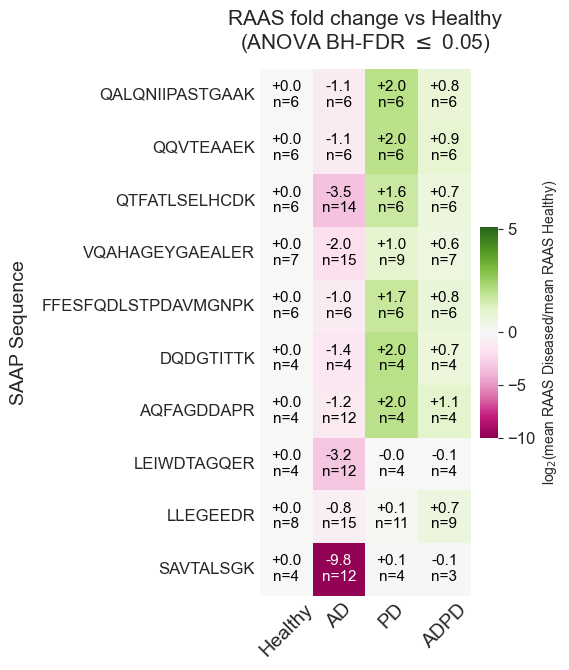

In [91]:
# Heatmap of log2 fold change in RAAS vs Healthy for the ANOVA-significant SAAPs.
# Per SAAP per group: log2FC = (mean RAAS[group] - mean RAAS[Healthy]) * log2(10); Healthy column = 0.
# Cells annotated with the fold change and the number of samples (n) backing each group mean.
sig = anova_df.loc[anova_df['significant']].sort_values('fdr')
keep = raas_long[raas_long['MTP_seq'].isin(sig['MTP_seq'])]

log2fc = pd.DataFrame({g: (sig[f'mean_{g}'] - sig['mean_Healthy']).values * np.log2(10)
                       for g in group_order}, index=sig['MTP_seq'].values)
cnt = keep.pivot_table(index='MTP_seq', columns='Sample Type', values='Reporter_RAAS', aggfunc='count').reindex(index=sig['MTP_seq'], columns=group_order)

annot = log2fc.copy().astype('object')
for saap in log2fc.index:
    for grp in log2fc.columns:
        annot.loc[saap, grp] = f"{log2fc.loc[saap, grp]:+.1f}\nn={int(cnt.loc[saap, grp])}"

q_by_saap = sig.set_index('MTP_seq')['fdr']
ylabels = list(log2fc.index)

# TwoSlopeNorm: an independent slope on each side of 0 keeps 0 white (no change vs Healthy) while
# -4 reaches the darkest blue and +5.3 the darkest red, so both tails saturate instead of washing out
from matplotlib.colors import TwoSlopeNorm
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=5.1)

sns.set_style('white')
cell = 0.5
fig, ax = plt.subplots(figsize=(len(group_order) * cell + 4, len(log2fc) * cell + 1.8))
sns.heatmap(log2fc, cmap='PiYG',
            annot=annot.values, fmt='', annot_kws={'size': 11, 'linespacing': 1.15},
            linewidths=0, square=True,
            cbar_kws={'label': 'log$_2$ FC vs Healthy', 'shrink': 0.4, 'pad': 0.02, 'aspect': 12},
            ax=ax)

qm = ax.collections[0]
qm.set_norm(norm)
qm.colorbar.update_normal(qm)

# recolor each annotation based on its cell's luminance
cmap_obj = plt.get_cmap('PiYG')
n_rows, n_cols = log2fc.shape
for i in range(n_rows):
    for j in range(n_cols):
        val = log2fc.values[i, j]
        rgba = cmap_obj(norm(val))
        # perceptual luminance
        lum = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
        text_color = 'black' if lum > 0.6 else 'white'
        ax.texts[i * n_cols + j].set_color(text_color)

ax.set_xticklabels(group_order, rotation=45, fontsize=14)
ax.set_yticklabels(ylabels, rotation=0, fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('SAAP Sequence', fontsize=14, labelpad=10)
ax.tick_params(length=0)
ax.set_title(f'RAAS fold change vs Healthy\n(ANOVA BH-FDR $\\leq$ {alpha})', fontsize=15, pad=14)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label('log$_2$(mean RAAS Diseased/mean RAAS Healthy)', fontsize=10)
cbar.outline.set_visible(False)

fig.tight_layout()
plt.savefig(PLOT_DIR + 'RAAS_log2FC_vs_healthy_neurodegen_heatmap_Pooled.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'RAAS_log2FC_vs_healthy_neurodegen_heatmap_Pooled.png', dpi=300, bbox_inches='tight')
plt.show()

# Changes with Neurodegenerative State (Bai 2020)

In [92]:
# Prepare a SAAP_quant_df 
print(SAAP_quant_df_filtered)
SAAP_quant_df_Bai = SAAP_quant_df_filtered.copy()

      Dataset         MTP_seq          BP_seq  aa_sub tmt_set  \
0       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
1       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
2       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
3       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
4       acgb1     ASSSSLSMDEK     ASWSSLSMDEK  W to S      S1   
...       ...             ...             ...     ...     ...   
16709  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
16710  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
16711  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
16712  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   
16713  pooled  LIDQIVSSITASLR  LIGQIVSSITASLR  G to D      S1   

       Positional_probability  spectral_entropy  delta_RT  SAAP_PEP  BP_PEP  \
0                         1.0            1.5401    0.7461       0.0     0.0   
1                         1.0            1.5401    0.7461    

In [93]:
def simplify_sampletype(x):
    if x.startswith('PSP'):
        return 'PSP'
    elif x.startswith('CTRL'):
        return 'Healthy'
    elif x.startswith('AD_Pool'):
        return 'AD_Pool'
    elif x.startswith('LPC'):
        return 'LPC'
    elif x.startswith('MCI'):
        return 'MCI'
    elif x.startswith ('HPC'):
        return 'HPC'
    return x

def simplify_dataset(x):
    if x.startswith('ACG') or x.startswith('acg'):
        return 'Ping'
    elif x.startswith('FC') or x.startswith('fc'):
        return 'Ping'
    elif x.startswith('Pooled ') or x.startswith('pooled'):
        return 'Bai'
    return x

SAAP_quant_df_Bai['Sample Type'] = SAAP_quant_df_Bai['Sample Type'].apply(simplify_sampletype)
print(SAAP_quant_df_Bai['Sample Type'].unique())

['PD' 'Healthy' 'ADPD' 'AD' 'LPC' 'AD_Pool' 'PSP' 'HPC' 'MCI']


In [ ]:
group_order = ['AD_Pool', 'LPC', 'MCI', 'HPC', 'PSP']

raas_long = SAAP_quant_df_Bai[['MTP_seq', 'Sample Type', 'Sample', 'Reporter_RAAS']].copy()
raas_long['Reporter_RAAS'] = pd.to_numeric(raas_long['Reporter_RAAS'], errors='coerce')
raas_long = raas_long.replace([np.inf, -np.inf], np.nan).dropna(subset=['Reporter_RAAS'])
raas_long = raas_long[raas_long['Sample Type'].isin(group_order)]
raas_long = raas_long.groupby(['MTP_seq', 'Sample Type', 'Sample'], as_index=False)['Reporter_RAAS'].median()

print(raas_long['Sample Type'].value_counts())

Sample Type
AD_Pool    1552
HPC        1552
MCI        1551
PSP        1551
LPC        1549
Name: count, dtype: int64
                   MTP_seq Sample Type         Sample  Reporter_RAAS
0     AAHVFFTDSSPDALFNELVK     AD_Pool    AD_Pool1_AD      -3.692281
1     AAHVFFTDSSPDALFNELVK     AD_Pool    AD_Pool2_AD      -3.722521
2     AAHVFFTDSSPDALFNELVK         HPC  HPC_Pool1_HPC      -3.746821
3     AAHVFFTDSSPDALFNELVK         HPC  HPC_Pool2_HPC      -3.729056
4     AAHVFFTDSSPDALFNELVK         LPC  LPC_Pool1_LPC      -3.795243
...                    ...         ...            ...            ...
7750      YTPEEIAMATVTALRK         LPC  LPC_Pool2_LPC      -3.267299
7751      YTPEEIAMATVTALRK         MCI  MCI_Pool1_MCI      -3.427037
7752      YTPEEIAMATVTALRK         MCI  MCI_Pool2_MCI      -3.190590
7753      YTPEEIAMATVTALRK         PSP  PSP_Pool1_PSP      -3.346092
7754      YTPEEIAMATVTALRK         PSP  PSP_Pool2_PSP      -3.307321

[7755 rows x 4 columns]


In [116]:
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

group_vals = {g: raas_long.loc[raas_long['Sample Type'] == g, 'Reporter_RAAS'].dropna().values
              for g in group_order}
print({g: len(v) for g, v in group_vals.items()})

stat_kw, p_kw = kruskal(*[group_vals[g] for g in group_order])
print(f'Kruskal-Wallis: H={stat_kw:.2f}, p={p_kw:.3e}')

rows = []
for g1, g2 in combinations(group_order, 2):
    stat, p = mannwhitneyu(group_vals[g1], group_vals[g2], alternative='two-sided')
    rows.append({'group1': g1, 'group2': g2, 'n1': len(group_vals[g1]), 'n2': len(group_vals[g2]),
                 'median1': np.median(group_vals[g1]), 'median2': np.median(group_vals[g2]),
                 'mwu_stat': stat, 'p_value': p})

pairwise_df = pd.DataFrame(rows).sort_values('p_value')
print('\nPairwise Mann-Whitney U (unpaired, pooled RAAS values):')
print(pairwise_df.to_string(index=False))

{'AD_Pool': 1552, 'LPC': 1549, 'MCI': 1551, 'HPC': 1552, 'PSP': 1551}
Kruskal-Wallis: H=1.13, p=8.893e-01

Pairwise Mann-Whitney U (unpaired, pooled RAAS values):
 group1 group2   n1   n2   median1   median2  mwu_stat  p_value
    LPC    HPC 1549 1552 -3.388092 -3.334593 1177285.0 0.321019
AD_Pool    LPC 1552 1549 -3.342743 -3.388092 1222236.0 0.417499
    LPC    MCI 1549 1551 -3.388092 -3.359986 1186533.0 0.554784
    LPC    PSP 1549 1551 -3.388092 -3.365935 1188554.0 0.610405
    HPC    PSP 1552 1551 -3.334593 -3.365935 1215726.0 0.626332
    MCI    HPC 1551 1552 -3.359986 -3.334593 1193670.0 0.691392
AD_Pool    PSP 1552 1551 -3.342743 -3.365935 1211286.0 0.757351
AD_Pool    MCI 1552 1551 -3.342743 -3.359986 1209321.0 0.817926
AD_Pool    HPC 1552 1552 -3.342743 -3.334593 1200120.0 0.865406
    MCI    PSP 1551 1551 -3.359986 -3.365935 1204747.0 0.937809


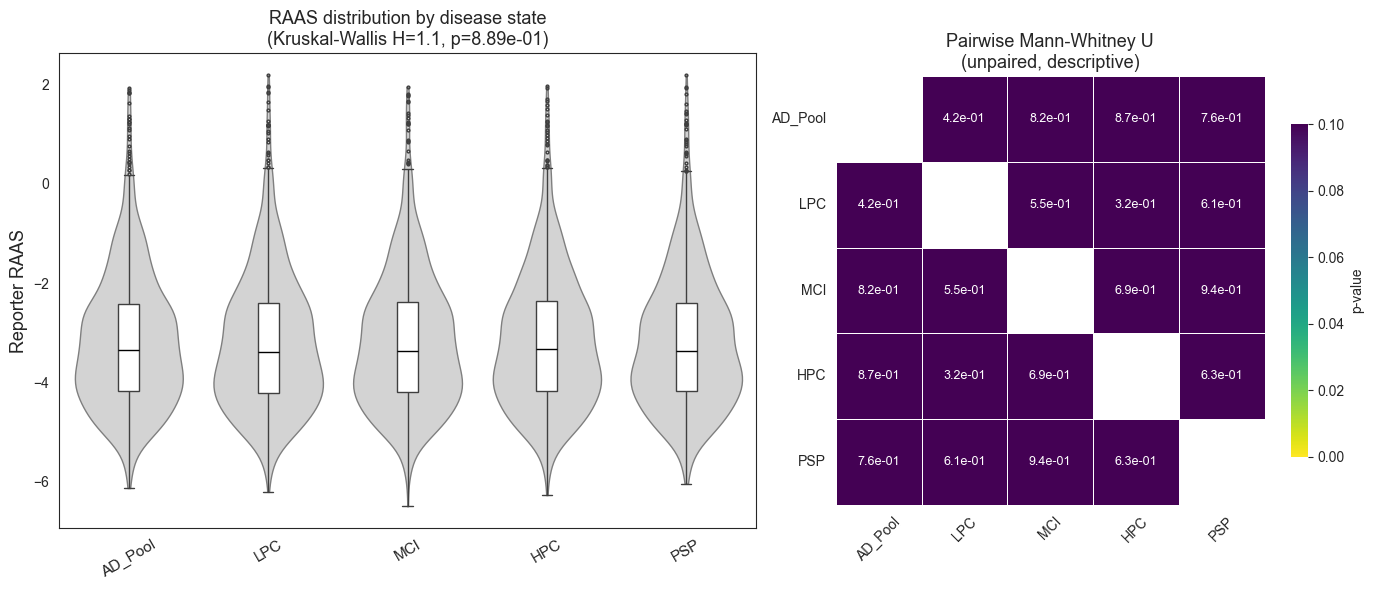

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1.3, 1]})

# left panel: distribution per group
sns.set_style('white')
plot_df = raas_long[raas_long['Sample Type'].isin(group_order)].copy()
sns.violinplot(data=plot_df, x='Sample Type', y='Reporter_RAAS', order=group_order,
                inner=None, cut=0, ax=axes[0], color='lightgray', linewidth=1)
sns.boxplot(data=plot_df, x='Sample Type', y='Reporter_RAAS', order=group_order,
            width=0.15, showcaps=True, boxprops={'facecolor': 'white', 'zorder': 2},
            whiskerprops={'zorder': 2}, medianprops={'color': 'black', 'zorder': 3},
            fliersize=2, ax=axes[0])
axes[0].set_xlabel('')
axes[0].set_ylabel('Reporter RAAS', fontsize=13)
axes[0].set_title(f'RAAS distribution by disease state\n(Kruskal-Wallis H={stat_kw:.1f}, p={p_kw:.2e})',
                   fontsize=13)
axes[0].tick_params(axis='x', rotation=30, labelsize=11)

# right panel: pairwise Mann-Whitney p-value heatmap
pmat = pd.DataFrame(index=group_order, columns=group_order, dtype=float)
for _, r in pairwise_df.iterrows():
    pmat.loc[r['group1'], r['group2']] = r['p_value']
    pmat.loc[r['group2'], r['group1']] = r['p_value']
np.fill_diagonal(pmat.values, np.nan)

sns.heatmap(pmat.astype(float), annot=True, fmt='.1e', cmap='viridis_r',
            vmin=0, vmax=0.1, cbar_kws={'label': 'p-value', 'shrink': 0.7},
            linewidths=0.5, linecolor='white', square=True, ax=axes[1],
            annot_kws={'size': 9})
axes[1].set_title('Pairwise Mann-Whitney U\n(unpaired, descriptive)', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

fig.tight_layout()
plt.savefig(PLOT_DIR + 'RAAS_distribution_kruskal_pairwise.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'RAAS_distribution_kruskal_pairwise.png', dpi=300, bbox_inches='tight')
plt.show()

In [118]:
min_reps = 2

means = raas_long.pivot_table(index='MTP_seq', columns='Sample Type',
                               values='Reporter_RAAS', aggfunc='mean').reindex(columns=group_order)
cnt = raas_long.pivot_table(index='MTP_seq', columns='Sample Type',
                             values='Reporter_RAAS', aggfunc='count').reindex(columns=group_order)

row_mean = means.mean(axis=1, skipna=True)
log2fc = (means.sub(row_mean, axis=0)) * np.log2(10)

detected_in = means.notna().sum(axis=1)
log2fc = log2fc.loc[detected_in >= 2]
cnt = cnt.loc[detected_in >= 2]

summary = pd.DataFrame({
    'n_groups_detected': detected_in.loc[log2fc.index],
    'max_abs_log2fc': log2fc.abs().max(axis=1),
    'direction': log2fc.idxmax(axis=1) + ' up / ' + log2fc.idxmin(axis=1) + ' down'
}).sort_values('max_abs_log2fc', ascending=False)

print(summary.head(20).to_string())

                              n_groups_detected  max_abs_log2fc              direction
MTP_seq                                                                               
QKLDILDQERGDLEK                               5        3.221199  AD_Pool up / LPC down
NLSTFAMDGK                                    5        3.174227  AD_Pool up / PSP down
LITAQQWLIK                                    5        3.081393      LPC up / PSP down
VDDSSEDKTEFLVK                                5        2.463618      MCI up / LPC down
MDADDSRPPK                                    5        2.454221      PSP up / LPC down
KAEGAAMEEEGTPK                                5        2.433790      LPC up / PSP down
AVLEQEETVAASR                                 5        2.409087      PSP up / MCI down
LFDQLLAEEK                                    5        2.241037      LPC up / PSP down
AQGPQQQPGSDGPSYAK                             5        2.208163      PSP up / MCI down
YEVSVSALR                                  

776 unique SAAPs going into the heatmap


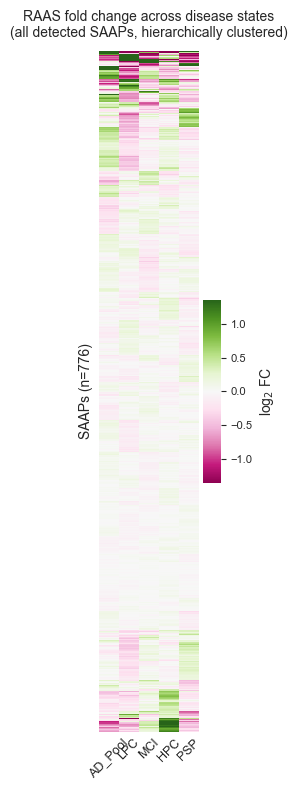

In [120]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist

group_order = ['AD_Pool', 'LPC', 'MCI', 'HPC', 'PSP']

means_all = raas_long.pivot_table(index='MTP_seq', columns='Sample Type',
                                   values='Reporter_RAAS', aggfunc='mean').reindex(columns=group_order)

# keep SAAPs detected in at least 2 groups so fold change is meaningful; drop fully-empty rows
means_all = means_all.loc[means_all.notna().sum(axis=1) >= 2]

row_mean = means_all.mean(axis=1, skipna=True)
log2fc_all = (means_all.sub(row_mean, axis=0)) * np.log2(10)

print(f'{len(log2fc_all)} unique SAAPs going into the heatmap')

# impute remaining NaNs to 0 (SAAP's own mean) purely for clustering distance calc;
# actual plotted values stay masked/NaN so missing data still renders blank
log2fc_for_clustering = log2fc_all.fillna(0)
row_linkage = sch.linkage(pdist(log2fc_for_clustering.values, metric='euclidean'), method='average')
row_order = sch.dendrogram(row_linkage, no_plot=True)['leaves']
log2fc_ordered = log2fc_all.iloc[row_order]

from matplotlib.colors import TwoSlopeNorm
vlim = np.nanpercentile(np.abs(log2fc_ordered.values), 99)  # clip extreme outliers, common in these figures
norm = TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

sns.set_style('white')
fig, ax = plt.subplots(figsize=(2.2, 8))  # tall, narrow — many rows, few columns
sns.heatmap(log2fc_ordered, cmap='PiYG', norm=norm, mask=log2fc_ordered.isna(),
            annot=False, linewidths=0, cbar_kws={'label': 'log$_2$ FC', 'shrink': 0.3, 'pad': 0.03, 'aspect': 10},
            xticklabels=group_order, yticklabels=False,
            ax=ax)

ax.set_xlabel('')
ax.set_ylabel(f'SAAPs (n={len(log2fc_ordered)})', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=9, length=0)
ax.set_title('RAAS fold change across disease states\n(all detected SAAPs, hierarchically clustered)',
             fontsize=10, pad=10)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.outline.set_visible(False)

fig.tight_layout()
plt.savefig(PLOT_DIR + 'RAAS_log2FC_all_SAAPs_dense_heatmap.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'RAAS_log2FC_all_SAAPs_dense_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()